# 🫀 Automatic Left Ventricle Segmentation in Myocardial Perfusion SPECT Images
## Using Custom Deep Learning Models (from Scratch)

**Dataset:** PhysioNet MPS Image Database v1.0 — https://doi.org/10.13026/ce2z-dw74  
**Models:** 2D U-Net | Attention U-Net | Normal CNN | ViTSeg  
**Framework:** PyTorch (no pretrained weights)

---
### 📋 Notebook Structure
1. Environment Setup & Imports  
2. Dataset Loading & File Matching  
3. Exploratory Data Analysis (EDA)  
4. Data Preprocessing Pipeline  
5. PyTorch Dataset & DataLoader  
6. Model Architectures (U-Net, Attention U-Net, Normal CNN, ViTSeg)  
7. Training Pipeline  
8. Evaluation & Metrics  
9. Results Visualization  
10. Comparative Analysis  

## 📦 1. Environment Setup & Imports

In [ ]:
!pip install pydicom nibabel scikit-image tqdm --quiet

In [ ]:


import os
import random
import warnings
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import pydicom
import nibabel as nib
from scipy.ndimage import rotate as ndrotate
from skimage.metrics import hausdorff_distance
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Libraries loaded successfully')
print(f'🖥️  Device : {DEVICE}')
print(f'🔦  PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'🎮  GPU    : {torch.cuda.get_device_name(0)}')

✅ Libraries loaded successfully
🖥️  Device : cpu
🔦  PyTorch: 2.10.0+cpu


## 📂 2. Dataset Loading & File Matching

In [ ]:
import os, zipfile

BASE_DIR    = "/content" # Changed to a Colab-friendly base directory
ZIP_PATH    = os.path.join(BASE_DIR, 'PhysioNet.zip') # Updated ZIP_PATH based on user's input
EXTRACT_DIR = os.path.join(BASE_DIR, 'extracted_data')
CKPT_DIR    = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# Extract zip if not already done
if not os.path.exists(EXTRACT_DIR):
    print('Extracting dataset ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print('Extraction complete!')
else:
    print('Dataset already extracted.')

# Dynamically locate DICOM and mask dirs (handles special chars in folder name)
DICOM_PATH = None
MASK_PATH  = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if any(f.endswith('.dcm') for f in files):  DICOM_PATH = root
    if any(f.endswith('.nii') for f in files):  MASK_PATH  = root

assert DICOM_PATH, 'DICOM directory not found!'
assert MASK_PATH,  'Mask directory not found!'
print(f'DICOM path : {DICOM_PATH}')
print(f'Mask  path : {MASK_PATH}')
print(f'CKPT  path : {CKPT_DIR}')

Dataset already extracted.
DICOM path : /content/extracted_data/Heart Blood Flow imaging database
/DICOM
Mask  path : /content/extracted_data/Heart Blood Flow imaging database
/segmentation_masks
CKPT  path : /content/checkpoints


In [ ]:
def get_matched_data():
    d_files = {f.replace('.dcm', ''): os.path.join(DICOM_PATH, f)
               for f in os.listdir(DICOM_PATH) if f.endswith('.dcm')}
    m_files = {f.replace('_mask.nii', ''): os.path.join(MASK_PATH, f)
               for f in os.listdir(MASK_PATH)  if f.endswith('.nii')}
    matched = sorted(set(d_files.keys()) & set(m_files.keys()))
    return matched, d_files, m_files

matched_uids, dicom_files, mask_files = get_matched_data()

# Exclude orphans and corrupted mask (identified during dataset check)
BAD_UIDS = {
    '1.2.840.4267.32.133915863660751213294859829083303067507',  # no mask
    '1.2.840.4267.32.192052152995804567307143658737269603225',  # no mask
    '1.2.840.4267.32.99818898917938660874830436103391257990',   # corrupted mask (19 KB)
}
matched_uids = [uid for uid in matched_uids if uid not in BAD_UIDS]

print('=' * 55)
print('  DATASET FILE MATCHING SUMMARY')
print('=' * 55)
print(f'  Total DICOM volumes       : {len(dicom_files):>5}')
print(f'  Total NIfTI masks         : {len(mask_files):>5}')
print(f'  Bad UIDs excluded         : {len(BAD_UIDS):>5}')
print(f'  Matched pairs (clean)     : {len(matched_uids):>5}')
print('=' * 55)


  DATASET FILE MATCHING SUMMARY
  Total DICOM volumes       :   103
  Total NIfTI masks         :   100
  Bad UIDs excluded         :     3
  Matched pairs (clean)     :    99


In [ ]:
# ── Metadata extraction ───────────────────────────────────────────────────
meta_records = []

if len(matched_uids) > 0:
    for uid in matched_uids:
        # Added force=True to handle non-standard DICOM headers common in this dataset
        ds = pydicom.dcmread(dicom_files[uid], force=True)
        mask_vol = nib.load(mask_files[uid]).get_fdata()
        pixel_arr = ds.pixel_array  # (slices, rows, cols)

        meta_records.append({
            'uid'        : uid,
            'n_slices'   : pixel_arr.shape[0] if pixel_arr.ndim == 3 else 1,
            'rows'       : ds.Rows,
            'cols'       : ds.Columns,
            'spacing'    : str(list(ds.PixelSpacing)) if hasattr(ds, 'PixelSpacing') else 'N/A',
            'mask_voxels': int(mask_vol.sum()),
            'px_mean'    : round(float(pixel_arr.mean()), 2),
            'px_std'     : round(float(pixel_arr.std()),  2),
            'px_max'     : int(pixel_arr.max()),
        })

df_meta = pd.DataFrame(meta_records)

print('📋 Metadata for all matched patients:')
if not df_meta.empty:
    display(df_meta.describe(include='all').round(2))
else:
    print('⚠️ No matched data found to describe. Please ensure cell cabe5c69 shows Matched pairs > 0.')

📋 Metadata for all matched patients:


,uid,n_slices,rows,cols,spacing,mask_voxels,px_mean,px_std,px_max
count,99,99.0,99.0,99.0,99,99.00,99.00,99.00,99.0
unique,99,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
top,1.2.840.4267.32.102843376980518437893525476318...,NaN,NaN,NaN,"['4.000000', '4.000000']",NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,99,NaN,NaN,NaN,NaN
mean,NaN,50.0,70.0,70.0,NaN,3819.95,1590.85,2910.43,32767.0
std,NaN,0.0,0.0,0.0,NaN,918.33,460.42,806.23,0.0
min,NaN,50.0,70.0,70.0,NaN,2048.00,111.40,373.63,32767.0
25%,NaN,50.0,70.0,70.0,NaN,3145.50,1342.06,2428.86,32767.0
50%,NaN,50.0,70.0,70.0,NaN,3763.00,1578.18,2931.11,32767.0
75%,NaN,50.0,70.0,70.0,NaN,4432.00,1875.51,3514.32,32767.0


## 🔍 3. Exploratory Data Analysis (EDA)

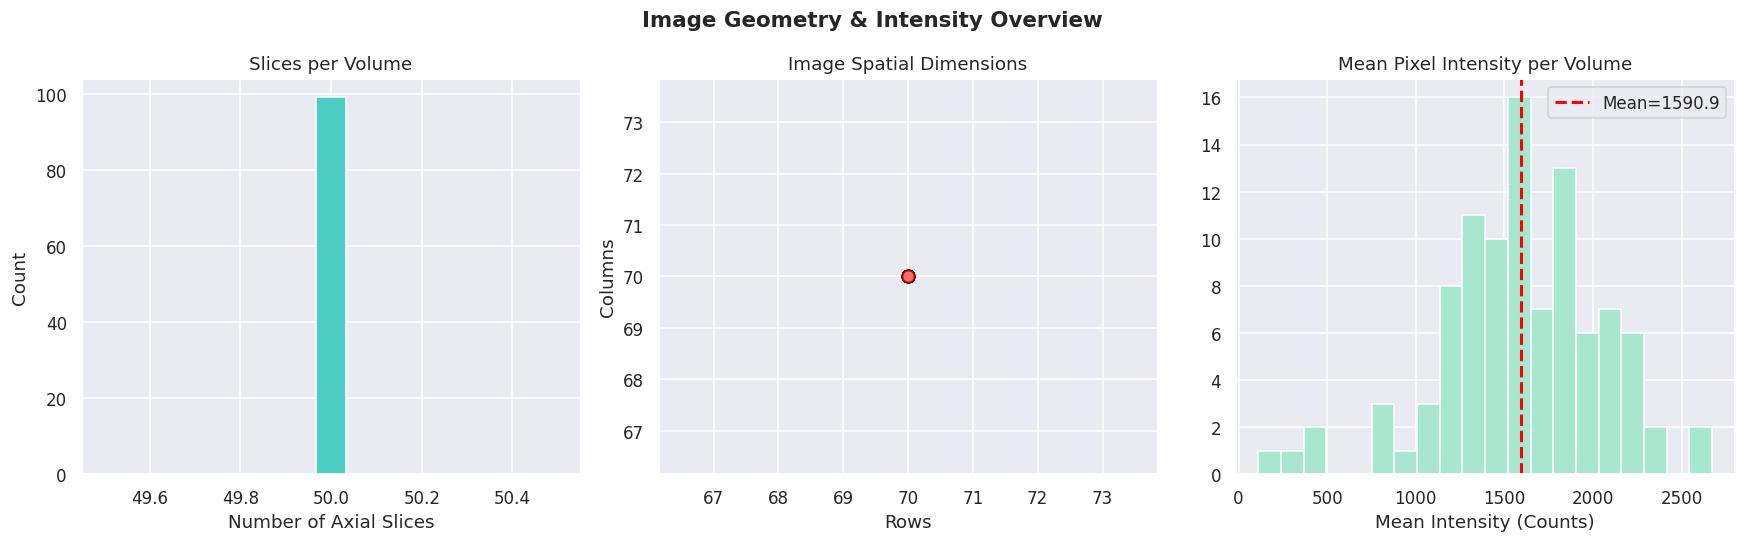

In [ ]:
# ── 3.1 Image Geometry Consistency Check ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Image Geometry & Intensity Overview', fontsize=14, fontweight='bold')

# Safely plot n_slices if present
if 'n_slices' in df_meta.columns:
    axes[0].hist(df_meta['n_slices'], bins=min(15, len(df_meta)), color='#4ECDC4', edgecolor='white')
    axes[0].set_title('Slices per Volume')
    axes[0].set_xlabel('Number of Axial Slices')
    axes[0].set_ylabel('Count')

# Image Dimensions
axes[1].scatter(df_meta['rows'], df_meta['cols'], alpha=0.6,
                color='#FF6B6B', edgecolors='darkred', s=60)
axes[1].set_title('Image Spatial Dimensions')
axes[1].set_xlabel('Rows')
axes[1].set_ylabel('Columns')

# Intensity Distribution
axes[2].hist(df_meta['px_mean'], bins=min(20, len(df_meta)), color='#A8E6CF', edgecolor='white')
axes[2].axvline(df_meta['px_mean'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean={df_meta['px_mean'].mean():.1f}")
axes[2].set_title('Mean Pixel Intensity per Volume')
axes[2].set_xlabel('Mean Intensity (Counts)')
axes[2].legend()

plt.tight_layout()
plt.show()

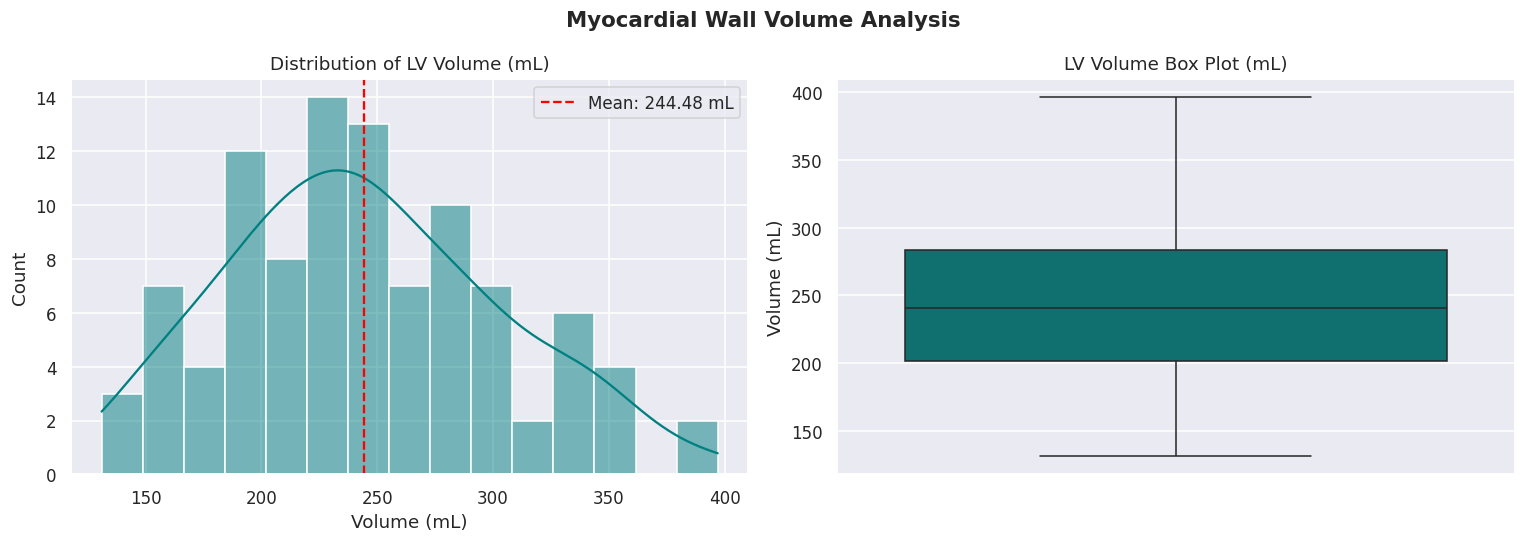

📊 LV Volume Stats:
count     99.000
mean     244.477
std       58.773
min      131.072
25%      201.312
50%      240.832
75%      283.648
max      396.928
Name: myo_volume_mL, dtype: float64


In [ ]:
# ── 3.2 Myocardial Volume Distribution ───────────────────────────────────
VOXEL_VOL_MM3 = 4 * 4 * 4  # 4mm isotropic
df_meta['myo_volume_mL'] = df_meta['mask_voxels'] * VOXEL_VOL_MM3 / 1000.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Myocardial Wall Volume Analysis', fontsize=14, fontweight='bold')

sns.histplot(df_meta['myo_volume_mL'], bins=15, color='teal', kde=True, ax=axes[0])
axes[0].set_title('Distribution of LV Volume (mL)')
axes[0].set_xlabel('Volume (mL)')
axes[0].axvline(df_meta['myo_volume_mL'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_meta['myo_volume_mL'].mean():.2f} mL")
axes[0].legend()

sns.boxplot(y=df_meta['myo_volume_mL'], color='teal', ax=axes[1])
axes[1].set_title('LV Volume Box Plot (mL)')
axes[1].set_ylabel('Volume (mL)')

plt.tight_layout()
plt.show()

print(f'📊 LV Volume Stats:')
print(df_meta['myo_volume_mL'].describe().round(3))

### 🖼️ Data Preprocessing Visualization: Augmentation Examples

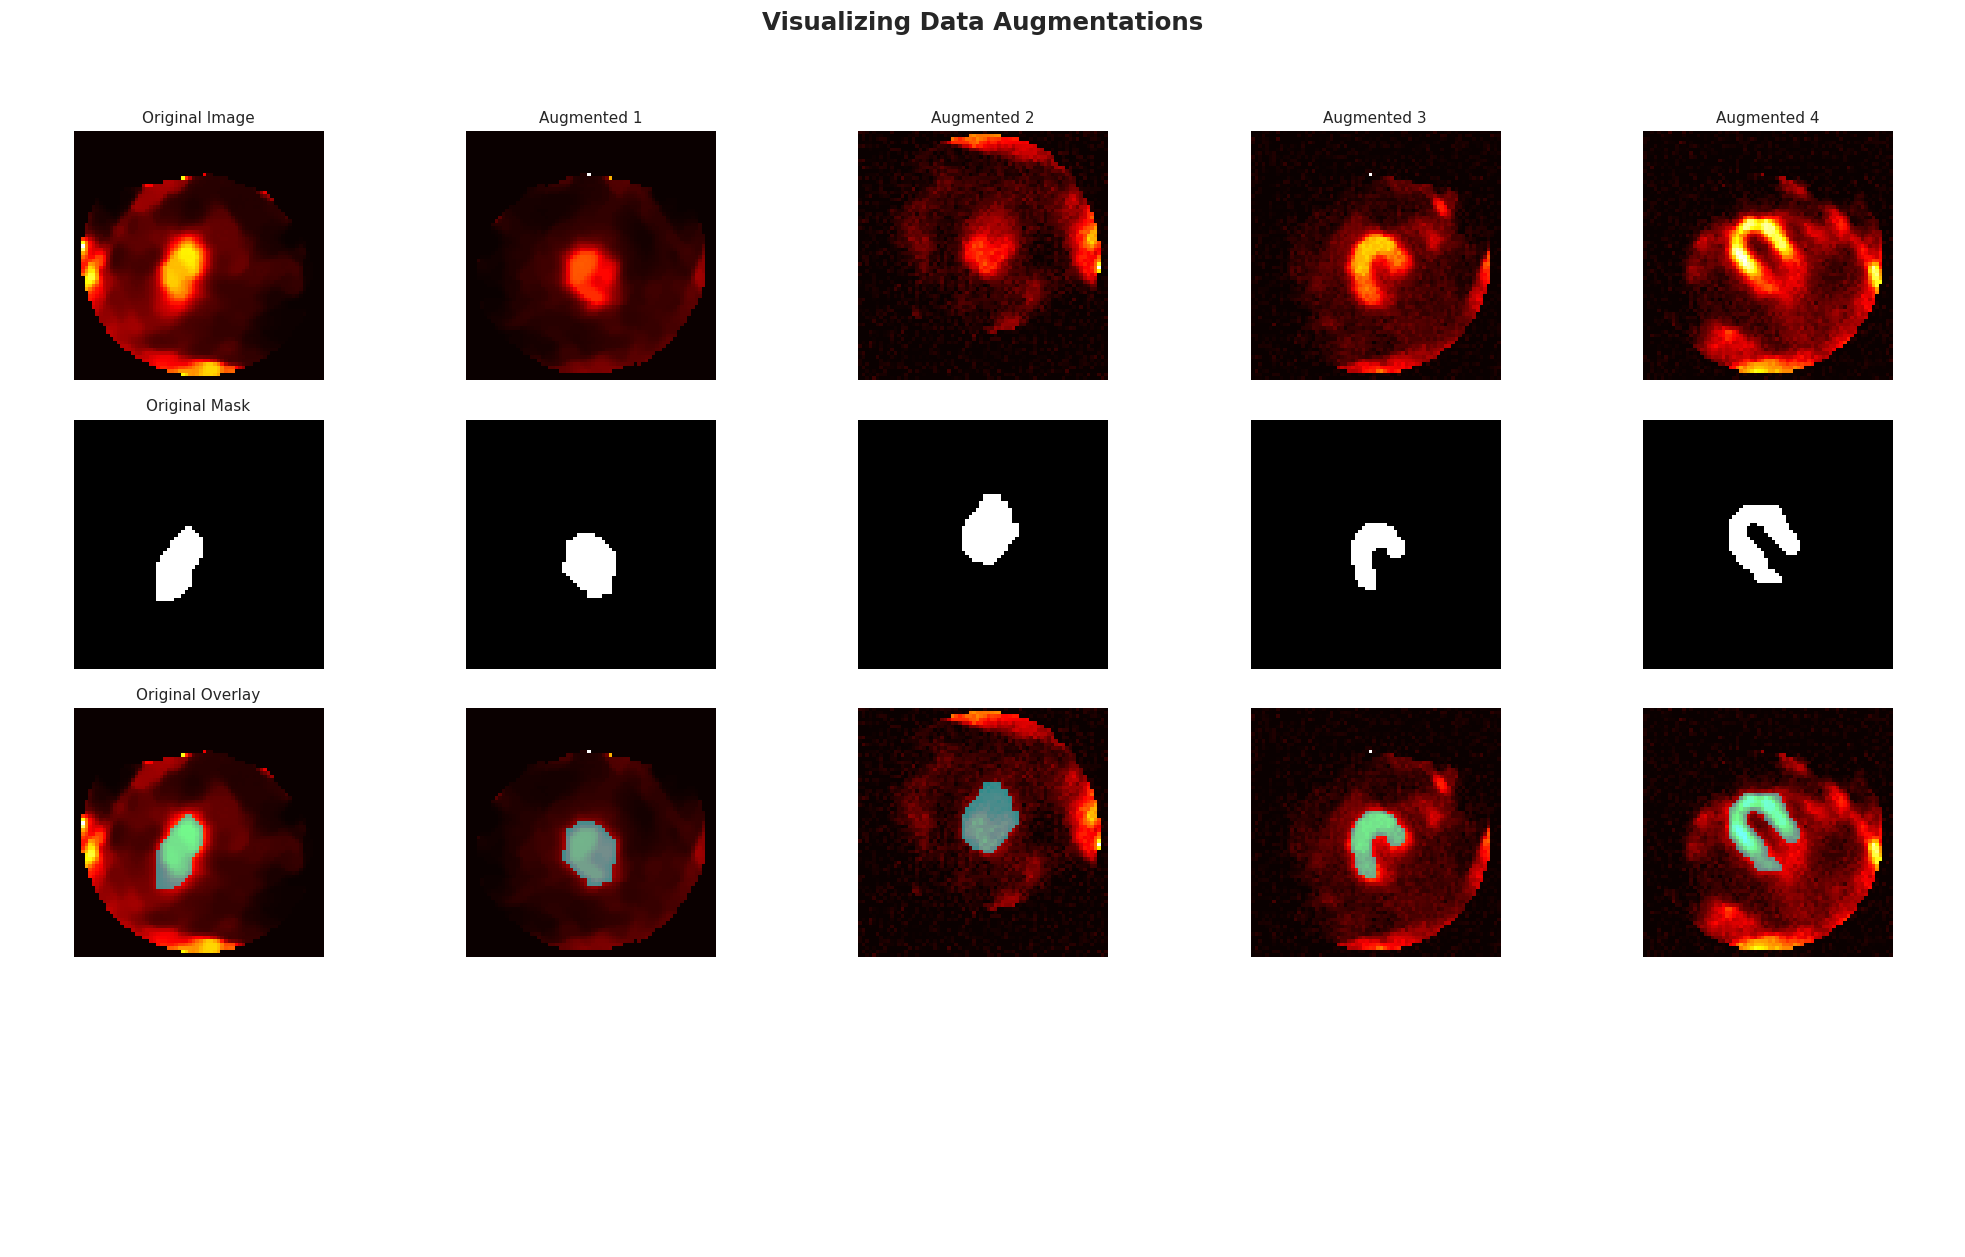

In [ ]:
import matplotlib.pyplot as plt

# Include the SPECTDataset class definition to ensure it's available
# This content is moved from cell cr2Ic-6Tt5tD
class SPECTDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset for SPECT LV segmentation.
    Each item: (image_tensor [1,H,W], mask_tensor [1,H,W])
    """
    def __init__(self, slice_list, augment=False):
        self.data    = slice_list
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, msk = self.data[idx]
        img = torch.from_numpy(img).float().unsqueeze(0)  # (1, H, W)
        msk = torch.from_numpy(msk).float().unsqueeze(0)  # (1, H, W)

        if self.augment:
            img, msk = self._augment(img, msk)

        return img, msk

    def _augment(self, img, msk):
        if random.random() > 0.5:
            img = TF.hflip(img); msk = TF.hflip(msk)
        if random.random() > 0.5:
            img = TF.vflip(img); msk = TF.vflip(msk)
        if random.random() > 0.5:
            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, fill=0)
            msk = TF.rotate(msk, angle, fill=0)
        if random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            img = torch.clamp(img * factor, 0.0, 1.0)
        if random.random() > 0.5:
            noise = torch.randn_like(img) * 0.02
            img   = torch.clamp(img + noise, 0.0, 1.0)
        return img, msk

# End of SPECTDataset class definition

# --- Start of code needed to define train_data for this cell ---
def load_pair(uid):
    """
    Load a DICOM volume and its corresponding NIfTI mask.
    Returns:
        img_vol  : np.float32 shape (n_slices, H, W), normalized to [0, 1]
        mask_vol : np.float32 binary shape (n_slices, H, W)
    """
    ds       = pydicom.dcmread(dicom_files[uid])
    img_vol  = ds.pixel_array.astype(np.float32)

    nii      = nib.load(mask_files[uid])
    mask_raw = nii.get_fdata().astype(np.float32)  # (70, 70, 50)
    mask_vol = np.transpose(mask_raw, (2, 1, 0))   # → (50, 70, 70)

    # Min-max normalize per volume
    v_min, v_max = img_vol.min(), img_vol.max()
    if v_max > v_min:
        img_vol = (img_vol - v_min) / (v_max - v_min)
    else:
        img_vol = np.zeros_like(img_vol)

    mask_vol = (mask_vol > 0.5).astype(np.float32)
    return img_vol, mask_vol


def extract_slices(uid, min_mask_pixels=10):
    """
    Extract 2D (image, mask) pairs from a volume.
    Keeps only slices with sufficient LV annotation.
    """
    img_vol, mask_vol = load_pair(uid)
    slices = []
    for i in range(img_vol.shape[0]):
        if mask_vol[i].sum() >= min_mask_pixels:
            slices.append((img_vol[i], mask_vol[i]))
    return slices


# Patient-level Train / Validation / Test Split
all_uids = matched_uids.copy()
random.shuffle(all_uids)

n_total = len(all_uids)

if n_total >= 3:
    n_test  = max(1, int(n_total * 0.15))
    n_val   = max(1, int(n_total * 0.15))
    n_train = n_total - n_test - n_val
else:
    n_train = n_total
    n_val   = 0
    n_test  = 0

train_uids = all_uids[:n_train]
val_uids   = all_uids[n_train:n_train + n_val]
test_uids  = all_uids[n_train + n_val:]

# If we have no validation data, use training data for validation to prevent pipeline crash
if len(val_uids) == 0 and len(train_uids) > 0:
    val_uids = train_uids
if len(test_uids) == 0 and len(train_uids) > 0:
    test_uids = train_uids

def build_slice_list(uid_list, min_mask_pixels=10):
    data = []
    for uid in uid_list:
        slices = extract_slices(uid, min_mask_pixels)
        data.extend(slices)
    return data

train_data = build_slice_list(train_uids)
# --- End of code needed to define train_data for this cell ---


fig, axes = plt.subplots(4, 5, figsize=(18, 12))
fig.suptitle('Visualizing Data Augmentations', fontsize=16, fontweight='bold')

# Create a dataset with augmentation for demonstration
aug_ds = SPECTDataset(train_data, augment=True)

# Get a random original image and mask (before augmentation)
original_img_t, original_msk_t = random.choice(train_data)
original_img_np = original_img_t.squeeze() # Removed .numpy()
original_msk_np = original_msk_t.squeeze() # Removed .numpy()

# Display the original image and mask
axes[0, 0].imshow(original_img_np, cmap='hot')
axes[0, 0].set_title('Original Image', fontsize=10)
axes[0, 0].axis('off')

axes[1, 0].imshow(original_msk_np, cmap='gray')
axes[1, 0].set_title('Original Mask', fontsize=10)
axes[1, 0].axis('off')

axes[2, 0].imshow(original_img_np, cmap='hot')
masked = np.ma.masked_where(original_msk_np == 0, original_msk_np)
axes[2, 0].imshow(masked, cmap='cool', alpha=0.55)
axes[2, 0].set_title('Original Overlay', fontsize=10)
axes[2, 0].axis('off')

# Display various augmented versions
for col in range(1, 5):
    # Get an augmented sample (each call will produce different augmentation)
    img_t, msk_t = aug_ds[random.randint(0, len(aug_ds) - 1)]
    img_np = img_t.squeeze().numpy()
    msk_np = msk_t.squeeze().numpy()

    axes[0, col].imshow(img_np, cmap='hot')
    axes[0, col].set_title(f'Augmented {col}', fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(msk_np, cmap='gray')
    axes[1, col].axis('off')

    axes[2, col].imshow(img_np, cmap='hot')
    masked = np.ma.masked_where(msk_np == 0, msk_np)
    axes[2, col].imshow(masked, cmap='cool', alpha=0.55)
    axes[2, col].axis('off')

# Remove the unused 4th row for aesthetic
for col in range(5):
    axes[3, col].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

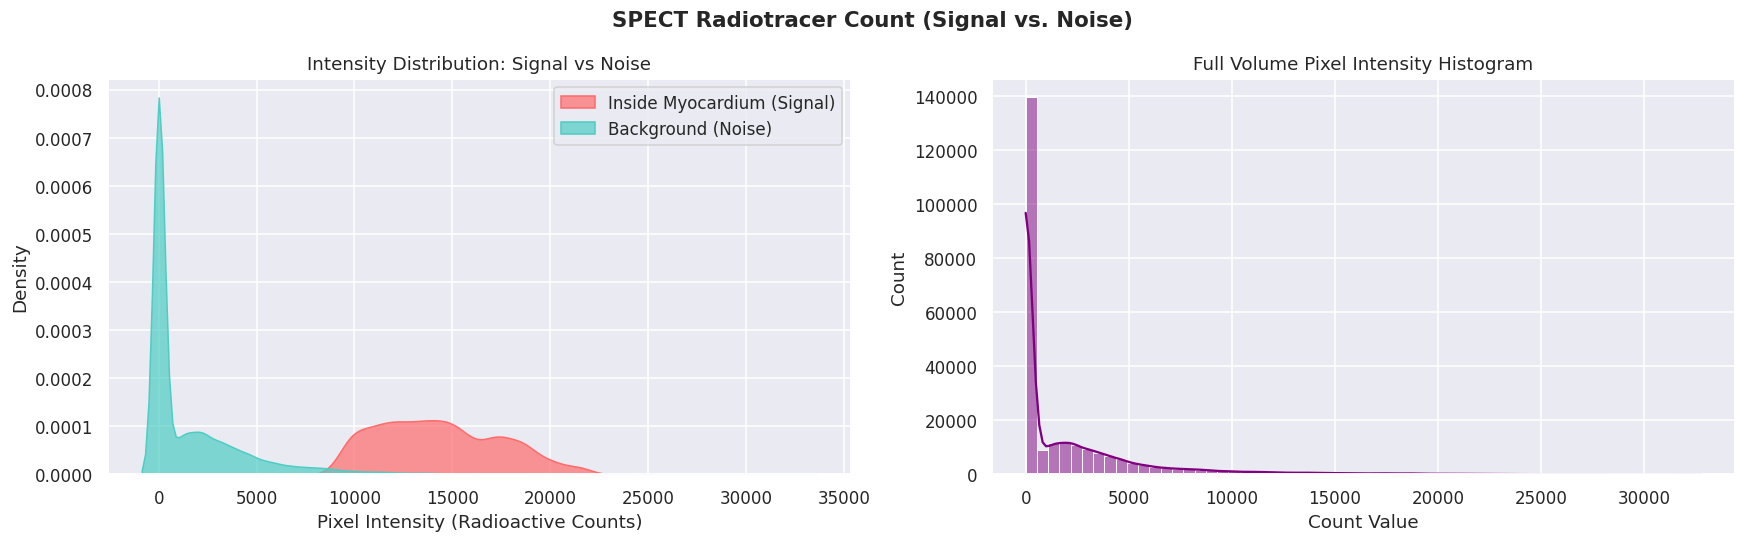

📡 Signal mean (inside myocardium) : 14332.80
📡 Noise  std  (background)        : 3442.38
📡 Signal-to-Noise Ratio (SNR)     : 4.164


In [ ]:
# ── 3.3 SPECT Radiotracer Intensity Distribution ──────────────────────────
sample_uid = matched_uids[0]
sample_dcm  = pydicom.dcmread(dicom_files[sample_uid]).pixel_array
sample_mask_raw = nib.load(mask_files[sample_uid]).get_fdata()
sample_mask = np.transpose(sample_mask_raw, (2, 1, 0))  # → (50, 70, 70)

inside  = sample_dcm[sample_mask == 1].flatten()
outside = sample_dcm[sample_mask == 0].flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('SPECT Radiotracer Count (Signal vs. Noise)', fontsize=14, fontweight='bold')

sns.kdeplot(inside,  label='Inside Myocardium (Signal)', fill=True,
            color='#FF6B6B', alpha=0.7, ax=axes[0])
sns.kdeplot(outside, label='Background (Noise)',         fill=True,
            color='#4ECDC4', alpha=0.7, ax=axes[0])
axes[0].set_title('Intensity Distribution: Signal vs Noise')
axes[0].set_xlabel('Pixel Intensity (Radioactive Counts)')
axes[0].legend()

sns.histplot(sample_dcm.flatten(), bins=60, color='purple', kde=True, ax=axes[1])
axes[1].set_title('Full Volume Pixel Intensity Histogram')
axes[1].set_xlabel('Count Value')

plt.tight_layout()
plt.show()

snr = inside.mean() / (outside.std() + 1e-8)
print(f'📡 Signal mean (inside myocardium) : {inside.mean():.2f}')
print(f'📡 Noise  std  (background)        : {outside.std():.2f}')
print(f'📡 Signal-to-Noise Ratio (SNR)     : {snr:.3f}')

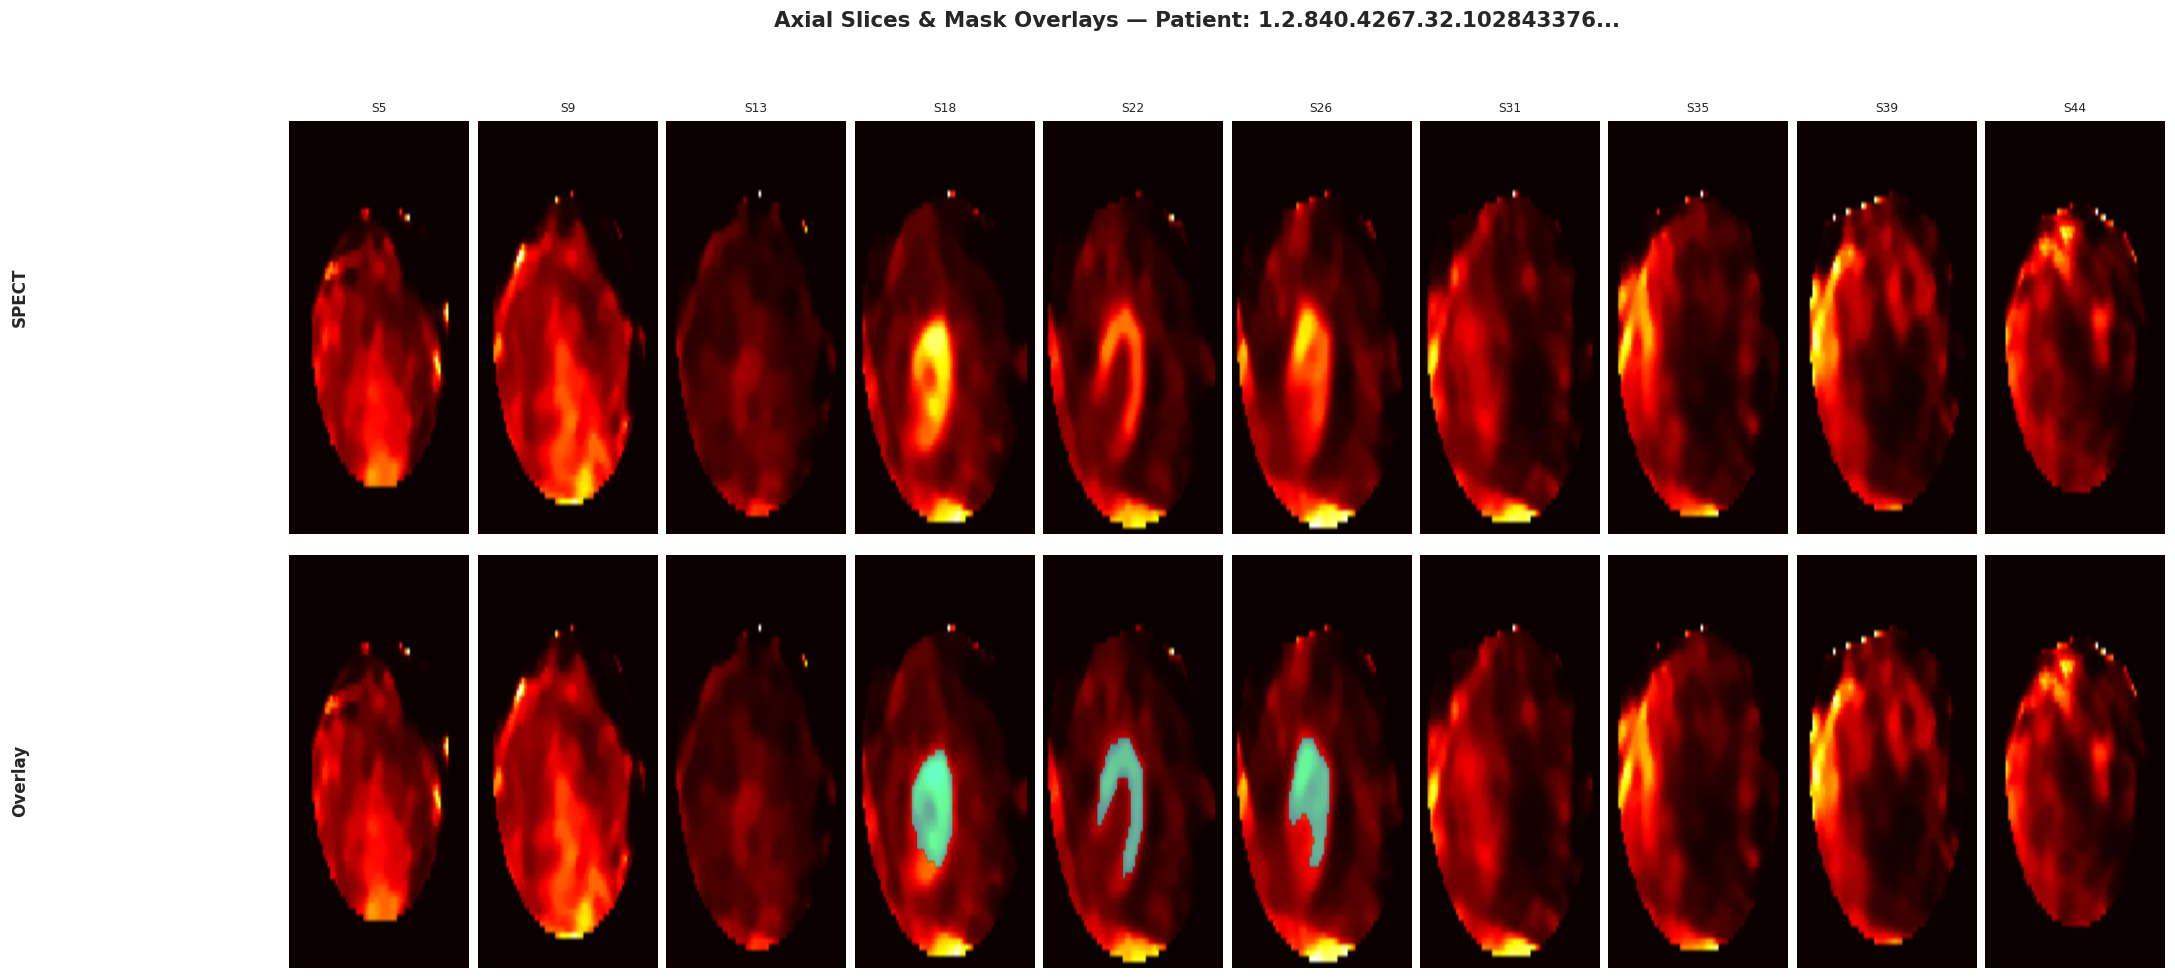

In [ ]:
# ── 3.4 Axial Slice Montage + Overlay ─────────────────────────────────────
fig = plt.figure(figsize=(22, 10))
fig.suptitle(f'Axial Slices & Mask Overlays — Patient: {sample_uid[:25]}...',
             fontsize=14, fontweight='bold')

slice_indices = np.linspace(5, 44, 10).astype(int)
gs = gridspec.GridSpec(2, 10, figure=fig, hspace=0.05, wspace=0.05)

for i, s_idx in enumerate(slice_indices):
    ax1 = fig.add_subplot(gs[0, i])
    ax1.imshow(sample_dcm[s_idx], cmap='hot', aspect='auto')
    ax1.set_title(f'S{s_idx}', fontsize=8)
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[1, i])
    ax2.imshow(sample_dcm[s_idx], cmap='hot', aspect='auto')
    if sample_mask[s_idx].sum() > 0:
        masked = np.ma.masked_where(sample_mask[s_idx] == 0, sample_mask[s_idx])
        ax2.imshow(masked, cmap='cool', alpha=0.6, aspect='auto')
    ax2.axis('off')

fig.text(0.01, 0.72, 'SPECT', va='center', rotation='vertical',
         fontsize=11, fontweight='bold')
fig.text(0.01, 0.28, 'Overlay', va='center', rotation='vertical',
         fontsize=11, fontweight='bold')
plt.show()

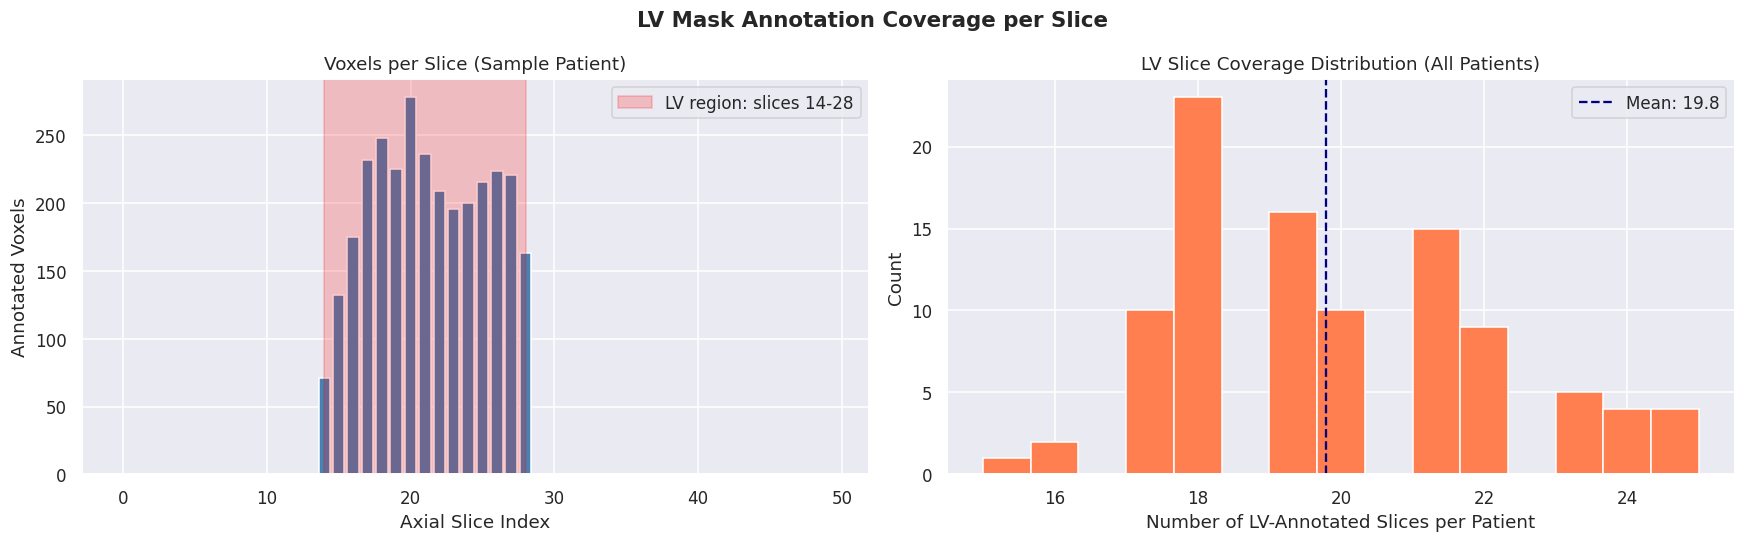

In [ ]:
# ── 3.5 Mask Coverage per Slice ─────────────────────────────────────────
coverage = [sample_mask[i].sum() for i in range(sample_mask.shape[0])]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('LV Mask Annotation Coverage per Slice', fontsize=14, fontweight='bold')

axes[0].bar(range(len(coverage)), coverage, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Axial Slice Index')
axes[0].set_ylabel('Annotated Voxels')
axes[0].set_title('Voxels per Slice (Sample Patient)')
non_zero = [i for i, c in enumerate(coverage) if c > 0]
if non_zero:
    axes[0].axvspan(min(non_zero), max(non_zero), alpha=0.2, color='red',
                    label=f'LV region: slices {min(non_zero)}-{max(non_zero)}')
axes[0].legend()

all_coverages = []
for uid in matched_uids:
    m = nib.load(mask_files[uid]).get_fdata()
    m_t = np.transpose(m, (2, 1, 0))
    all_coverages.append(sum(1 for i in range(m_t.shape[0]) if m_t[i].sum() > 0))

axes[1].hist(all_coverages, bins=15, color='coral', edgecolor='white')
axes[1].set_xlabel('Number of LV-Annotated Slices per Patient')
axes[1].set_ylabel('Count')
axes[1].set_title('LV Slice Coverage Distribution (All Patients)')
axes[1].axvline(np.mean(all_coverages), color='navy', linestyle='--',
                label=f'Mean: {np.mean(all_coverages):.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## ⚙️ 4. Data Preprocessing Pipeline

In [ ]:
def load_pair(uid):
    """
    Load a DICOM volume and its corresponding NIfTI mask.
    Returns:
        img_vol  : np.float32 shape (n_slices, H, W), normalized to [0, 1]
        mask_vol : np.float32 binary shape (n_slices, H, W)
    """
    ds       = pydicom.dcmread(dicom_files[uid])
    img_vol  = ds.pixel_array.astype(np.float32)

    nii      = nib.load(mask_files[uid])
    mask_raw = nii.get_fdata().astype(np.float32)  # (70, 70, 50)
    mask_vol = np.transpose(mask_raw, (2, 1, 0))   # → (50, 70, 70)

    # Min-max normalize per volume
    v_min, v_max = img_vol.min(), img_vol.max()
    if v_max > v_min:
        img_vol = (img_vol - v_min) / (v_max - v_min)
    else:
        img_vol = np.zeros_like(img_vol)

    mask_vol = (mask_vol > 0.5).astype(np.float32)
    return img_vol, mask_vol


def extract_slices(uid, min_mask_pixels=10):
    """
    Extract 2D (image, mask) pairs from a volume.
    Keeps only slices with sufficient LV annotation.
    """
    img_vol, mask_vol = load_pair(uid)
    slices = []
    for i in range(img_vol.shape[0]):
        if mask_vol[i].sum() >= min_mask_pixels:
            slices.append((img_vol[i], mask_vol[i]))
    return slices


print('✅ Preprocessing functions defined.')
img_v, msk_v = load_pair(matched_uids[0])
print(f'   Image volume shape  : {img_v.shape}  dtype: {img_v.dtype}')
print(f'   Mask volume  shape  : {msk_v.shape}  dtype: {msk_v.dtype}')
print(f'   Image range         : [{img_v.min():.3f}, {img_v.max():.3f}]')
print(f'   Mask unique values  : {np.unique(msk_v)}')

✅ Preprocessing functions defined.
   Image volume shape  : (50, 70, 70)  dtype: float32
   Mask volume  shape  : (50, 70, 70)  dtype: float32
   Image range         : [0.000, 1.000]
   Mask unique values  : [0. 1.]


In [ ]:
# ── Patient-level Train / Validation / Test Split ─────────────────────────
all_uids = matched_uids.copy()
random.shuffle(all_uids)

n_total = len(all_uids)

if n_total >= 3:
    n_test  = max(1, int(n_total * 0.15))
    n_val   = max(1, int(n_total * 0.15))
    n_train = n_total - n_test - n_val
else:
    # Fallback for very small or synthetic datasets
    n_train = n_total
    n_val   = 0
    n_test  = 0

train_uids = all_uids[:n_train]
val_uids   = all_uids[n_train:n_train + n_val]
test_uids  = all_uids[n_train + n_val:]

# If we have no validation data, use training data for validation to prevent pipeline crash
if len(val_uids) == 0 and len(train_uids) > 0:
    val_uids = train_uids
if len(test_uids) == 0 and len(train_uids) > 0:
    test_uids = train_uids

print('=' * 40)
print('  PATIENT-LEVEL DATA SPLIT')
print('=' * 40)
print(f'  Train patients : {len(train_uids):>4} ({len(train_uids)/n_total*100:.1f}%)')
print(f'  Val   patients : {len(val_uids):>4} ({len(val_uids)/n_total*100:.1f}%)')
print(f'  Test  patients : {len(test_uids):>4} ({len(test_uids)/n_total*100:.1f}%)')
print('=' * 40)

  PATIENT-LEVEL DATA SPLIT
  Train patients :   71 (71.7%)
  Val   patients :   14 (14.1%)
  Test  patients :   14 (14.1%)


In [ ]:
# ── Build Slice-Level Datasets ────────────────────────────────────────────
def build_slice_list(uid_list, min_mask_pixels=10):
    data = []
    for uid in uid_list:
        slices = extract_slices(uid, min_mask_pixels)
        data.extend(slices)
    print(f'  → {len(uid_list)} patients → {len(data)} slices')
    return data

print('Building slice lists...')
print('Train:', end=' '); train_data = build_slice_list(train_uids)
print('Val  :', end=' '); val_data   = build_slice_list(val_uids)
print('Test :', end=' '); test_data  = build_slice_list(test_uids)

total_slices = len(train_data) + len(val_data) + len(test_data)
print(f'\n  Total annotated slices used : {total_slices}')

Building slice lists...
Train:   → 71 patients → 1390 slices
Val  :   → 14 patients → 264 slices
Test :   → 14 patients → 267 slices

  Total annotated slices used : 1921


## 🗃️ 5. PyTorch Dataset & DataLoader

In [ ]:
class SPECTDataset(Dataset):
    """
    PyTorch Dataset for SPECT LV segmentation.
    Each item: (image_tensor [1,H,W], mask_tensor [1,H,W])
    """
    def __init__(self, slice_list, augment=False):
        self.data    = slice_list
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, msk = self.data[idx]
        img = torch.from_numpy(img).float().unsqueeze(0)  # (1, H, W)
        msk = torch.from_numpy(msk).float().unsqueeze(0)  # (1, H, W)

        if self.augment:
            img, msk = self._augment(img, msk)

        return img, msk

    def _augment(self, img, msk):
        if random.random() > 0.5:
            img = TF.hflip(img); msk = TF.hflip(msk)
        if random.random() > 0.5:
            img = TF.vflip(img); msk = TF.vflip(msk)
        if random.random() > 0.5:
            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, fill=0)
            msk = TF.rotate(msk, angle, fill=0)
        if random.random() > 0.5:
            factor = random.uniform(0.8, 1.2)
            img = torch.clamp(img * factor, 0.0, 1.0)
        if random.random() > 0.5:
            noise = torch.randn_like(img) * 0.02
            img   = torch.clamp(img + noise, 0.0, 1.0)
        return img, msk


BATCH_SIZE = 16

train_ds = SPECTDataset(train_data, augment=True)
val_ds   = SPECTDataset(val_data,   augment=False)
test_ds  = SPECTDataset(test_data,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'✅ DataLoaders created')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val   batches : {len(val_loader)}')
print(f'   Test  batches : {len(test_loader)}')
imgs, msks = next(iter(train_loader))
print(f'   Batch image shape : {imgs.shape}')
print(f'   Batch mask  shape : {msks.shape}')

✅ DataLoaders created
   Train batches : 87
   Val   batches : 17
   Test  batches : 17
   Batch image shape : torch.Size([16, 1, 70, 70])
   Batch mask  shape : torch.Size([16, 1, 70, 70])


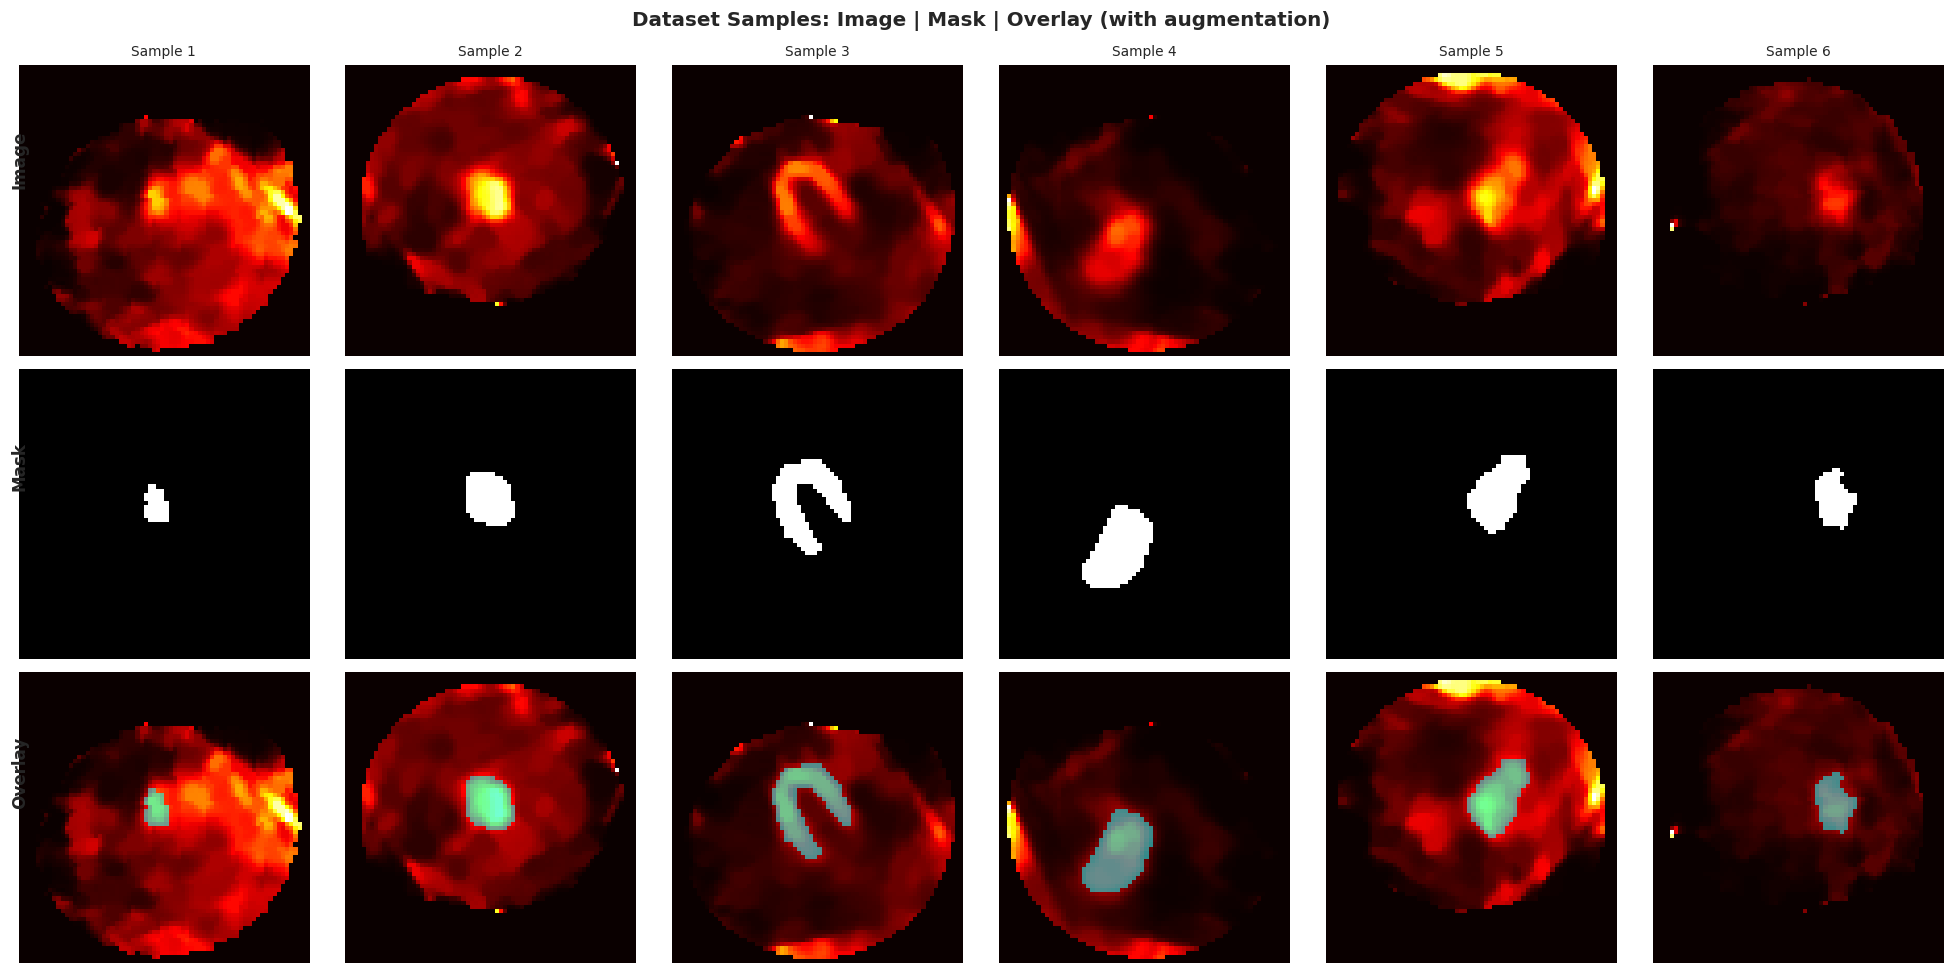

In [ ]:
# ── Visualize augmentation examples ──────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Dataset Samples: Image | Mask | Overlay (with augmentation)',
             fontsize=13, fontweight='bold')

aug_ds  = SPECTDataset(train_data, augment=True)
indices = random.sample(range(len(aug_ds)), 6)

for col, idx in enumerate(indices):
    img_t, msk_t = aug_ds[idx]
    img_np = img_t.squeeze().numpy()
    msk_np = msk_t.squeeze().numpy()

    axes[0, col].imshow(img_np, cmap='hot')
    axes[0, col].set_title(f'Sample {col+1}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(msk_np, cmap='gray')
    axes[1, col].axis('off')

    axes[2, col].imshow(img_np, cmap='hot')
    masked = np.ma.masked_where(msk_np == 0, msk_np)
    axes[2, col].imshow(masked, cmap='cool', alpha=0.55)
    axes[2, col].axis('off')

for row, lbl in enumerate(['Image', 'Mask', 'Overlay']):
    fig.text(0.01, 0.83 - row*0.31, lbl, va='center',
             rotation='vertical', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧠 6. Model Architectures

In [ ]:
# ══════════════════════════════════════════════════════════
# SHARED BUILDING BLOCKS
# ══════════════════════════════════════════════════════════

class DoubleConv(nn.Module):
    """Two (Conv2d → BN → ReLU) layers."""
    def __init__(self, in_ch, out_ch, mid_ch=None):
        super().__init__()
        mid_ch = mid_ch or out_ch
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),  nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class Down(nn.Module):
    """MaxPool2d(2) followed by DoubleConv."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x): return self.pool_conv(x)


class Up(nn.Module):
    """TransposedConv upsampling + concatenation + DoubleConv."""
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x  = self.up(x)
        dH = skip.size(2) - x.size(2)
        dW = skip.size(3) - x.size(3)
        x  = F.pad(x, [dW//2, dW - dW//2, dH//2, dH - dH//2])
        return self.conv(torch.cat([skip, x], dim=1))


print('✅ Shared building blocks ready.')

✅ Shared building blocks ready.


In [ ]:
# ══════════════════════════════════════════════════════════
# MODEL 1 — Standard 2D U-Net (from scratch)
# Encoder: 16→32→64→128  Bottleneck: 256
# ══════════════════════════════════════════════════════════

class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, features=(16, 32, 64, 128)):
        super().__init__()
        self.name = 'UNet'
        self.enc1 = DoubleConv(in_ch, features[0])
        self.enc2 = Down(features[0], features[1])
        self.enc3 = Down(features[1], features[2])
        self.enc4 = Down(features[2], features[3])
        self.bottleneck = Down(features[3], features[3] * 2)
        self.dec4 = Up(features[3]*2, features[3], features[3])
        self.dec3 = Up(features[3],   features[2], features[2])
        self.dec2 = Up(features[2],   features[1], features[1])
        self.dec1 = Up(features[1],   features[0], features[0])
        self.out  = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        b  = self.bottleneck(s4)
        x  = self.dec4(b,  s4)
        x  = self.dec3(x,  s3)
        x  = self.dec2(x,  s2)
        x  = self.dec1(x,  s1)
        return torch.sigmoid(self.out(x))


unet       = UNet().to(DEVICE)
dummy      = torch.randn(2, 1, 70, 70).to(DEVICE)
out        = unet(dummy)
params_unet = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f'✅ UNet — Output: {out.shape} | Params: {params_unet:,}')

✅ UNet — Output: torch.Size([2, 1, 70, 70]) | Params: 1,942,289


In [ ]:
# ══════════════════════════════════════════════════════════
# MODEL 2 — Attention U-Net  (Oktay et al., 2018)
# Encoder: 16→32→64  Bottleneck: 128  + attention gates
# ══════════════════════════════════════════════════════════

class AttentionGate(nn.Module):
    """
    Additive soft attention gate.
    α = σ( Ψ · ReLU(W_g·g + W_x·x + b) + b_Ψ )
    Returns x * α
    """
    def __init__(self, F_g, F_x, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(
            nn.Conv2d(F_x, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = F.interpolate(self.W_g(g), size=x.shape[2:], mode='bilinear', align_corners=True)
        x1 = self.W_x(x)
        return x * self.psi(self.relu(g1 + x1))


class AttentionUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, features=(16, 32, 64)):
        super().__init__()
        self.name = 'AttentionUNet'
        self.enc1 = DoubleConv(in_ch, features[0])
        self.enc2 = Down(features[0], features[1])
        self.enc3 = Down(features[1], features[2])
        self.bottleneck = Down(features[2], features[2] * 2)
        self.ag3  = AttentionGate(features[2]*2, features[2], features[2]//2)
        self.ag2  = AttentionGate(features[2],   features[1], features[1]//2)
        self.ag1  = AttentionGate(features[1],   features[0], features[0]//2)
        self.dec3 = Up(features[2]*2, features[2], features[2])
        self.dec2 = Up(features[2],   features[1], features[1])
        self.dec1 = Up(features[1],   features[0], features[0])
        self.out  = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        b  = self.bottleneck(s3)
        x  = self.dec3(b,  self.ag3(b,  s3))
        x  = self.dec2(x,  self.ag2(x,  s2))
        x  = self.dec1(x,  self.ag1(x,  s1))
        return torch.sigmoid(self.out(x))


att_unet   = AttentionUNet().to(DEVICE)
params_att = sum(p.numel() for p in att_unet.parameters() if p.requires_grad)
print(f'✅ AttentionUNet — Output: {att_unet(dummy).shape} | Params: {params_att:,}')

✅ AttentionUNet — Output: torch.Size([2, 1, 70, 70]) | Params: 490,914


## 🧠 6b. Additional Model Architectures (Normal CNN · ViT)

In [ ]:
# ══════════════════════════════════════════════════════════
# MODEL 3 — Normal CNN  (FCN-style Encoder-Decoder)
# No skip connections  |  Encoder: 32→64→128  |  Bilinear decode
# ══════════════════════════════════════════════════════════

class CNN(nn.Module):
    """Standard FCN-style CNN without skip connections."""
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()
        self.name = 'NormalCNN'
        self.enc = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32,    32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32,  64, 3, padding=1, bias=False),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64,  64, 3, padding=1, bias=False),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.dec = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64,  32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.out = nn.Conv2d(32, out_ch, 1)

    def forward(self, x):
        feat = self.enc(x)
        feat = F.interpolate(feat, size=x.shape[2:], mode='bilinear', align_corners=True)
        return torch.sigmoid(self.out(self.dec(feat)))

normal_cnn  = NormalCNN().to(DEVICE)
params_ncnn = sum(p.numel() for p in normal_cnn.parameters() if p.requires_grad)
print(f'✅ NormalCNN   — Output: {normal_cnn(dummy).shape} | Params: {params_ncnn:,}')


✅ NormalCNN   — Output: torch.Size([2, 1, 70, 70]) | Params: 379,265


In [ ]:
# ══════════════════════════════════════════════════════════
# MODEL 4 — ViTSeg  (Vision Transformer Segmentation)
# Patch 7×7 → 100 tokens  |  embed=128  |  4 heads  |  4 layers
# ══════════════════════════════════════════════════════════

class PatchEmbed(nn.Module):
    """Split image into non-overlapping patches and linearly embed each."""
    def __init__(self, img_size=70, patch_size=7, in_ch=1, embed_dim=128):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                        # (B, E, H/p, W/p)
        B, E, gh, gw = x.shape
        x = x.flatten(2).transpose(1, 2)        # (B, N, E)
        return x, gh, gw


class TransformerBlock(nn.Module):
    """Standard ViT transformer block."""
    def __init__(self, embed_dim=128, n_heads=4, mlp_ratio=2, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim    = int(embed_dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        y, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x    = x + y
        x    = x + self.mlp(self.norm2(x))
        return x


class ViTSeg(nn.Module):

    def __init__(self, img_size=70, patch_size=7, in_ch=1, out_ch=1,
                 embed_dim=128, depth=4, n_heads=4, dec_ch=32):
        super().__init__()
        self.name        = 'ViTSeg'
        self.patch_size  = patch_size
        self.dec_ch      = dec_ch
        n_patches        = (img_size // patch_size) ** 2
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.blocks      = nn.Sequential(
            *[TransformerBlock(embed_dim, n_heads) for _ in range(depth)])
        self.norm        = nn.LayerNorm(embed_dim)
        # Decoder: project each patch token → p×p spatial pixels
        self.dec_proj    = nn.Linear(embed_dim, patch_size * patch_size * dec_ch)
        self.dec_conv    = nn.Sequential(
            nn.Conv2d(dec_ch, dec_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(dec_ch), nn.ReLU(inplace=True),
            nn.Conv2d(dec_ch, out_ch, 1),
        )
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B, _, H, W = x.shape
        p = self.patch_size
        tokens, gh, gw = self.patch_embed(x)                  # (B, N, E)
        cls    = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1) + self.pos_embed
        tokens = self.norm(self.blocks(tokens))
        patch_tokens = tokens[:, 1:]                           # (B, N, E)
        # Pixel-shuffle decode
        feat = self.dec_proj(patch_tokens)                     # (B, N, p*p*C)
        feat = feat.view(B, gh, gw, p, p, self.dec_ch)
        feat = feat.permute(0, 5, 1, 3, 2, 4).contiguous()    # (B,C,gh,p,gw,p)
        feat = feat.view(B, self.dec_ch, gh * p, gw * p)      # (B,C,H,W)
        feat = F.interpolate(feat, size=(H, W), mode='bilinear', align_corners=True)
        return torch.sigmoid(self.dec_conv(feat))

vit_seg    = ViTSeg().to(DEVICE)
params_vit = sum(p.numel() for p in vit_seg.parameters() if p.requires_grad)
print(f'✅ ViTSeg      — Output: {vit_seg(dummy).shape} | Params: {params_vit:,}')

print()
print('─' * 55)
print('  ALL 4 MODELS — PARAMETER COMPARISON')
print('─' * 55)
print(f'  UNet          : {params_unet:>10,}  parameters')
print(f'  AttentionUNet : {params_att:>10,}  parameters')
print(f'  NormalCNN     : {params_ncnn:>10,}  parameters')
print(f'  ViTSeg        : {params_vit:>10,}  parameters')
print('─' * 55)


✅ ViTSeg      — Output: torch.Size([2, 1, 70, 70]) | Params: 761,217

───────────────────────────────────────────────────────
  ALL 4 MODELS — PARAMETER COMPARISON
───────────────────────────────────────────────────────
  UNet          :  1,942,289  parameters
  AttentionUNet :    490,914  parameters
  NormalCNN     :    379,265  parameters
  ViTSeg        :    761,217  parameters
───────────────────────────────────────────────────────


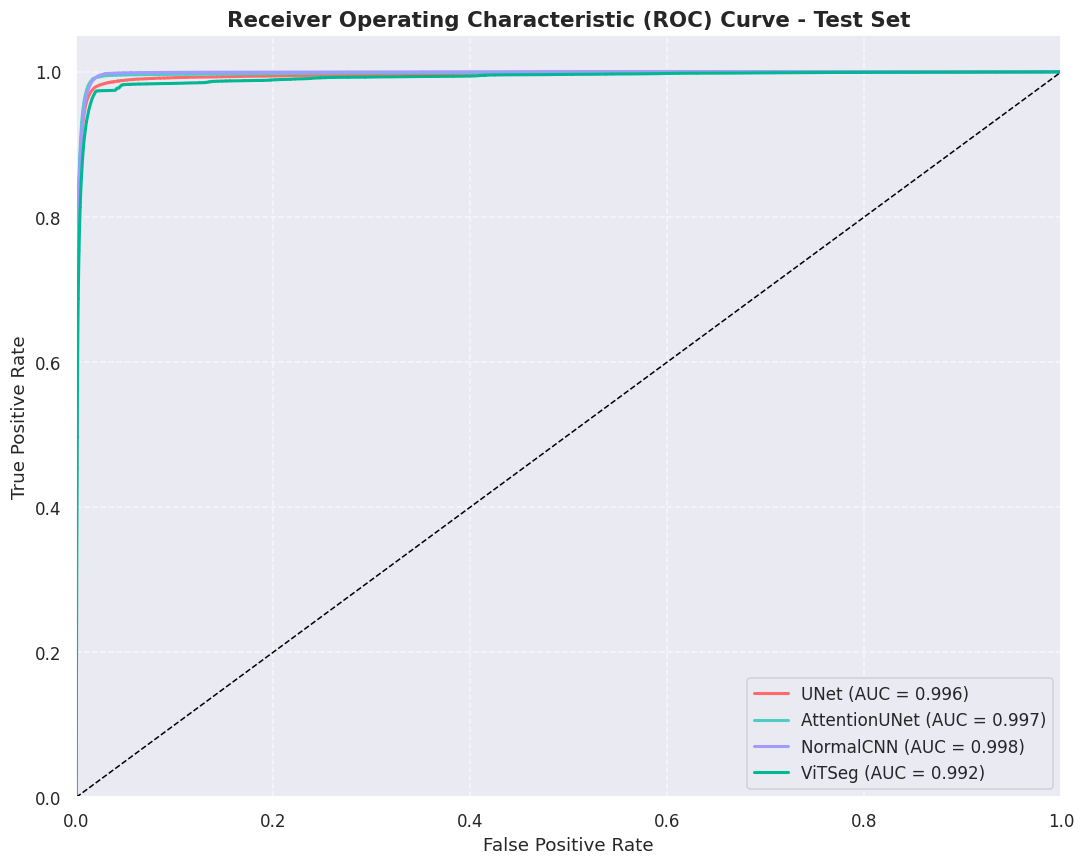

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.title('Receiver Operating Characteristic (ROC) Curve - Test Set', fontsize=14, fontweight='bold')

# Loop through each model's results
for name, res in results.items():
    # Flatten predictions and targets for ROC curve calculation
    y_true = res['targets'].cpu().numpy().flatten()
    y_score = res['preds'].cpu().numpy().flatten()

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=colors[name], lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1) # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

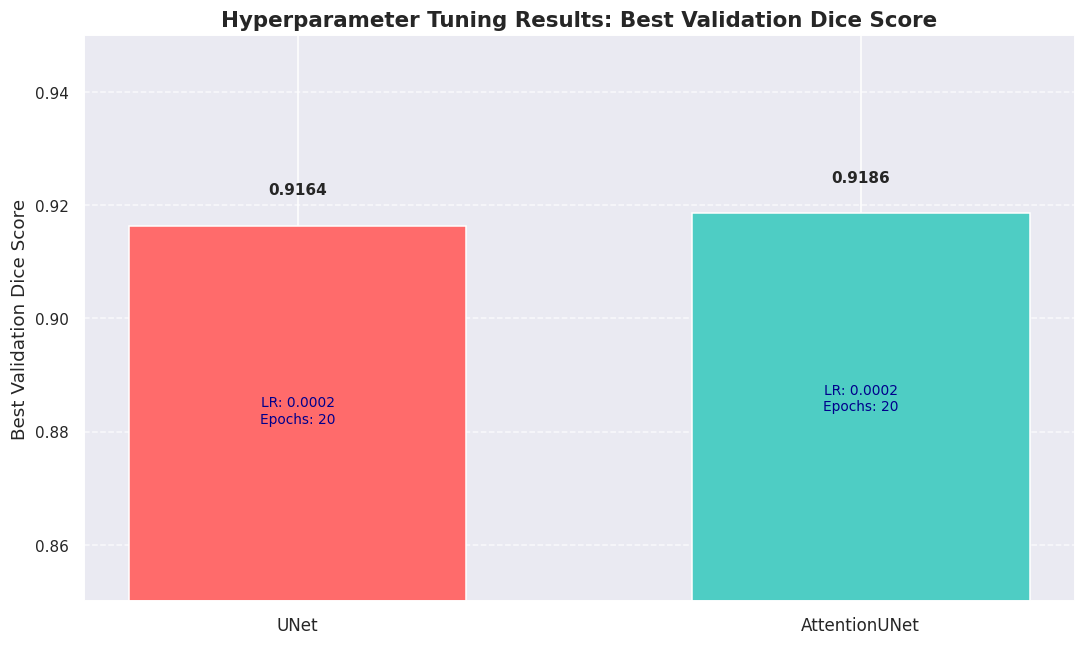


Detailed Tuning Results:
UNet: Best Val Dice = 0.9164, Best Params = {'lr': 0.0002, 'epochs': 20}
AttentionUNet: Best Val Dice = 0.9186, Best Params = {'lr': 0.0002, 'epochs': 20}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_names = list(tuning_results.keys())

best_dice_scores = [tuning_results[name]['best_val_dice'] for name in model_names]
best_params_labels = [f"LR: {tuning_results[name]['best_params']['lr']}\nEpochs: {tuning_results[name]['best_params']['epochs']}" for name in model_names]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, best_dice_scores, color=['#FF6B6B', '#4ECDC4'], width=0.6)

ax.set_ylim(0.85, 0.95) # Adjust y-limit to better show differences
ax.set_ylabel('Best Validation Dice Score', fontsize=12)
ax.set_title('Hyperparameter Tuning Results: Best Validation Dice Score', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)

# Add text labels for scores and parameters on top of bars
for bar, score, params_label in zip(bars, best_dice_scores, best_params_labels):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 0.03, # Adjust position for parameter labels
            params_label, ha='center', va='top', fontsize=9, color='darkblue')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print('\nDetailed Tuning Results:')
for model_name, res in tuning_results.items():
    print(f"{model_name}: Best Val Dice = {res['best_val_dice']:.4f}, Best Params = {res['best_params']}")

## 🏋️ 7. Training Pipeline

In [ ]:
# ── Loss: BCE + Dice ──────────────────────────────────────────────────────
class BCEDiceLoss(nn.Module):
    """L = λ·BCE + (1-λ)·(1 - Dice)"""
    def __init__(self, lam=0.5, smooth=1e-6):
        super().__init__()
        self.lam = lam; self.smooth = smooth
        self.bce = nn.BCELoss()

    def forward(self, pred, target):
        bce  = self.bce(pred, target)
        p, t = pred.view(-1), target.view(-1)
        dice = 1 - (2*(p*t).sum() + self.smooth) / (p.sum() + t.sum() + self.smooth)
        return self.lam * bce + (1 - self.lam) * dice


# ── Metrics ───────────────────────────────────────────────────────────────
def dice_score(pred, target, thr=0.5, smooth=1e-6):
    pb = (pred > thr).float()
    return ((2*(pb*target).sum() + smooth) / (pb.sum() + target.sum() + smooth)).item()

def iou_score(pred, target, thr=0.5, smooth=1e-6):
    pb = (pred > thr).float()
    inter = (pb*target).sum()
    return ((inter + smooth) / (pb.sum() + target.sum() - inter + smooth)).item()

def sensitivity(pred, target, thr=0.5, smooth=1e-6):
    pb = (pred > thr).float()
    tp = (pb*target).sum(); fn = ((1-pb)*target).sum()
    return ((tp + smooth) / (tp + fn + smooth)).item()

def specificity(pred, target, thr=0.5, smooth=1e-6):
    pb = (pred > thr).float()
    tn = ((1-pb)*(1-target)).sum(); fp = (pb*(1-target)).sum()
    return ((tn + smooth) / (tn + fp + smooth)).item()

print('✅ Loss and metric functions ready.')

✅ Loss and metric functions ready.


In [ ]:
def train_model(model, train_loader, val_loader,
                n_epochs=10, lr=1e-4, weight_decay=1e-5,
                patience=5, device=DEVICE):
    """
    Training loop:
    - Adam + Cosine Annealing Warm Restarts
    - BCE + Dice loss
    - Early stopping on val Dice
    - Best checkpoint restored on exit
    """
    model      = model.to(device)
    criterion  = BCEDiceLoss(lam=0.5)
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=30)

    history        = defaultdict(list)
    best_val_dice  = 0.0
    patience_count = 0
    best_state     = None

    for epoch in range(1, n_epochs + 1):
        # Train
        model.train()
        tr_loss = tr_dice = 0.0
        for imgs, msks in train_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            optimizer.zero_grad()
            preds = model(imgs)
            loss  = criterion(preds, msks)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item()
            tr_dice += dice_score(preds.detach(), msks)
        scheduler.step()

        # Validate
        model.eval()
        vl_loss = vl_dice = vl_iou = 0.0
        with torch.no_grad():
            for imgs, msks in val_loader:
                imgs, msks = imgs.to(device), msks.to(device)
                preds = model(imgs)
                vl_loss += criterion(preds, msks).item()
                vl_dice += dice_score(preds, msks)
                vl_iou  += iou_score(preds,  msks)

        ntr, nvl = len(train_loader), len(val_loader)
        tr_loss /= ntr; tr_dice /= ntr
        vl_loss /= nvl; vl_dice /= nvl; vl_iou /= nvl

        history['train_loss'].append(tr_loss)
        history['train_dice'].append(tr_dice)
        history['val_loss'].append(vl_loss)
        history['val_dice'].append(vl_dice)
        history['val_iou'].append(vl_iou)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        if vl_dice > best_val_dice:
            best_val_dice  = vl_dice
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Ep {epoch:>3}/{n_epochs}  '
                  f'tr_loss={tr_loss:.4f}  tr_dice={tr_dice:.4f}  '
                  f'vl_loss={vl_loss:.4f}  vl_dice={vl_dice:.4f}  '
                  f'[best={best_val_dice:.4f}]')

        if patience_count >= patience:
            print(f'  ⏹️  Early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history['best_val_dice'] = best_val_dice
    return dict(history)


print('✅ train_model() ready.')

✅ train_model() ready.


In [ ]:
# ── Train all FOUR models ───────────────────────────────────────────────
models_cfg = [
    ('UNet',          UNet()),
    ('AttentionUNet', AttentionUNet()),
    ('NormalCNN',     NormalCNN()),
    ('ViTSeg',        ViTSeg()),
]

trained_models   = {}
training_history = {}

colors = {
    'UNet':          '#FF6B6B',
    'AttentionUNet': '#4ECDC4',
    'NormalCNN':     '#A29BFE',
    'ViTSeg':        '#00B894',
}

for model_name, model in models_cfg:
    print('\n' + '='*62)
    print(f'  🚀 Training: {model_name}')
    print('='*62)
    t0   = time.time()
    hist = train_model(model, train_loader, val_loader,
                       n_epochs=10, lr=1e-4, patience=5)
    elapsed = time.time() - t0
    print(f'  ✅ Done in {elapsed/60:.1f} min  |  Best Val Dice: {hist["best_val_dice"]:.4f}')
    trained_models[model_name]   = model
    training_history[model_name] = hist



  🚀 Training: UNet
  Ep   1/10  tr_loss=0.7276  tr_dice=0.3524  vl_loss=0.6457  vl_dice=0.6207  [best=0.6207]
  Ep  10/10  tr_loss=0.5186  tr_dice=0.8908  vl_loss=0.5179  vl_dice=0.8617  [best=0.9040]
  ✅ Done in 10.1 min  |  Best Val Dice: 0.9040

  🚀 Training: AttentionUNet
  Ep   1/10  tr_loss=0.7169  tr_dice=0.5137  vl_loss=0.6624  vl_dice=0.7232  [best=0.7232]
  Ep  10/10  tr_loss=0.5487  tr_dice=0.8888  vl_loss=0.5437  vl_dice=0.8841  [best=0.8874]
  ✅ Done in 9.4 min  |  Best Val Dice: 0.8874

  🚀 Training: NormalCNN
  Ep   1/10  tr_loss=0.6512  tr_dice=0.6603  vl_loss=0.6088  vl_dice=0.8140  [best=0.8140]
  Ep  10/10  tr_loss=0.4532  tr_dice=0.8592  vl_loss=0.4455  vl_dice=0.8038  [best=0.8843]
  ✅ Done in 25.1 min  |  Best Val Dice: 0.8843

  🚀 Training: ViTSeg
  Ep   1/10  tr_loss=0.8078  tr_dice=0.1612  vl_loss=0.7375  vl_dice=0.3670  [best=0.3670]
  Ep  10/10  tr_loss=0.4974  tr_dice=0.8508  vl_loss=0.4899  vl_dice=0.8380  [best=0.8571]
  ✅ Done in 7.7 min  |  Best Val Dic

## 📊 8. Evaluation & Metrics

In [ ]:
def compute_hd95(pred_np, target_np):
    try:
        if pred_np.sum() == 0 or target_np.sum() == 0:
            return np.nan
        return float(hausdorff_distance(pred_np.astype(bool), target_np.astype(bool)))
    except Exception:
        return np.nan


def evaluate_model(model, data_loader, device=DEVICE, threshold=0.5):
    model.eval()
    all_dice, all_iou, all_sens, all_spec, all_hd = [], [], [], [], []
    all_preds, all_targets = [], []

    # Calculate parameters
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Calculate inference time (50 forward passes, batch=1)
    dummy1 = torch.randn(1, 1, 70, 70).to(device)
    t0 = time.time()
    with torch.no_grad():
        for _ in range(50): model(dummy1)
    infer_ms = (time.time() - t0) / 50 * 1000

    with torch.no_grad():
        for imgs, msks in data_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            preds = model(imgs)
            all_dice.append(dice_score(preds, msks, threshold))
            all_iou.append(iou_score(preds,   msks, threshold))
            all_sens.append(sensitivity(preds, msks, threshold))
            all_spec.append(specificity(preds, msks, threshold))

            preds_bin = (preds > threshold).float().cpu().numpy()
            msks_np   = msks.cpu().numpy()
            for i in range(preds_bin.shape[0]):
                all_hd.append(compute_hd95(preds_bin[i,0], msks_np[i,0]))

            all_preds.append(preds.cpu())
            all_targets.append(msks.cpu())

    return {
        'dice'       : np.nanmean(all_dice),
        'iou'        : np.nanmean(all_iou),
        'sensitivity': np.nanmean(all_sens),
        'specificity': np.nanmean(all_spec),
        'hd95'       : np.nanmean([h for h in all_hd if not np.isnan(h)]),
        'params'     : params,
        'inference_ms': round(infer_ms, 3),
        'dice_list'  : all_dice,
        'preds'      : torch.cat(all_preds),
        'targets'    : torch.cat(all_targets),
    }


# __Run evaluation on test set ────────────────────────────────────────────
results = {}
for name, model in trained_models.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    res = evaluate_model(model, test_loader)
    results[name] = res
    print(f'Dice={res["dice"]:.4f}  IoU={res["iou"]:.4f}  HD95={res["hd95"]:.2f}')

print('\n✅ Evaluation complete.')

Evaluating UNet... Dice=0.8931  IoU=0.8097  HD95=3.00
Evaluating AttentionUNet... Dice=0.8816  IoU=0.7923  HD95=3.12
Evaluating NormalCNN... Dice=0.8818  IoU=0.7921  HD95=4.13
Evaluating ViTSeg... Dice=0.8551  IoU=0.7512  HD95=4.42

✅ Evaluation complete.


In [ ]:
# ── Pretty Results Table ──────────────────────────────────────────────────
rows = []
for name, res in results.items():
    rows.append({
        'Model'          : name,
        'Dice (DSC) ↑'   : f"{res['dice']:.4f}",
        'IoU ↑'          : f"{res['iou']:.4f}",
        'Sensitivity ↑'  : f"{res['sensitivity']:.4f}",
        'Specificity ↑'  : f"{res['specificity']:.4f}",
        'HD95 ↓ (px)'    : f"{res['hd95']:.2f}",
        'Parameters'     : f"{res['params']:,}",
        'Infer (ms) ↓'   : f"{res['inference_ms']:.2f}",
    })

df_res = pd.DataFrame(rows).set_index('Model')
print('\n📊 TEST SET RESULTS')
print('='*85)
display(df_res)
print('='*85)


📊 TEST SET RESULTS


,Dice (DSC) ↑,IoU ↑,Sensitivity ↑,Specificity ↑,HD95 ↓ (px),Parameters,Infer (ms) ↓
Model,,,,,,,
UNet,0.8931,0.8097,0.9191,0.9943,3.00,"1,942,289",16.94
AttentionUNet,0.8816,0.7923,0.9743,0.9901,3.12,"490,914",15.02
NormalCNN,0.8818,0.7921,0.9636,0.9908,4.13,"379,265",28.29
ViTSeg,0.8551,0.7512,0.9361,0.9893,4.42,"761,217",12.43


## 📈 9. Results Visualization

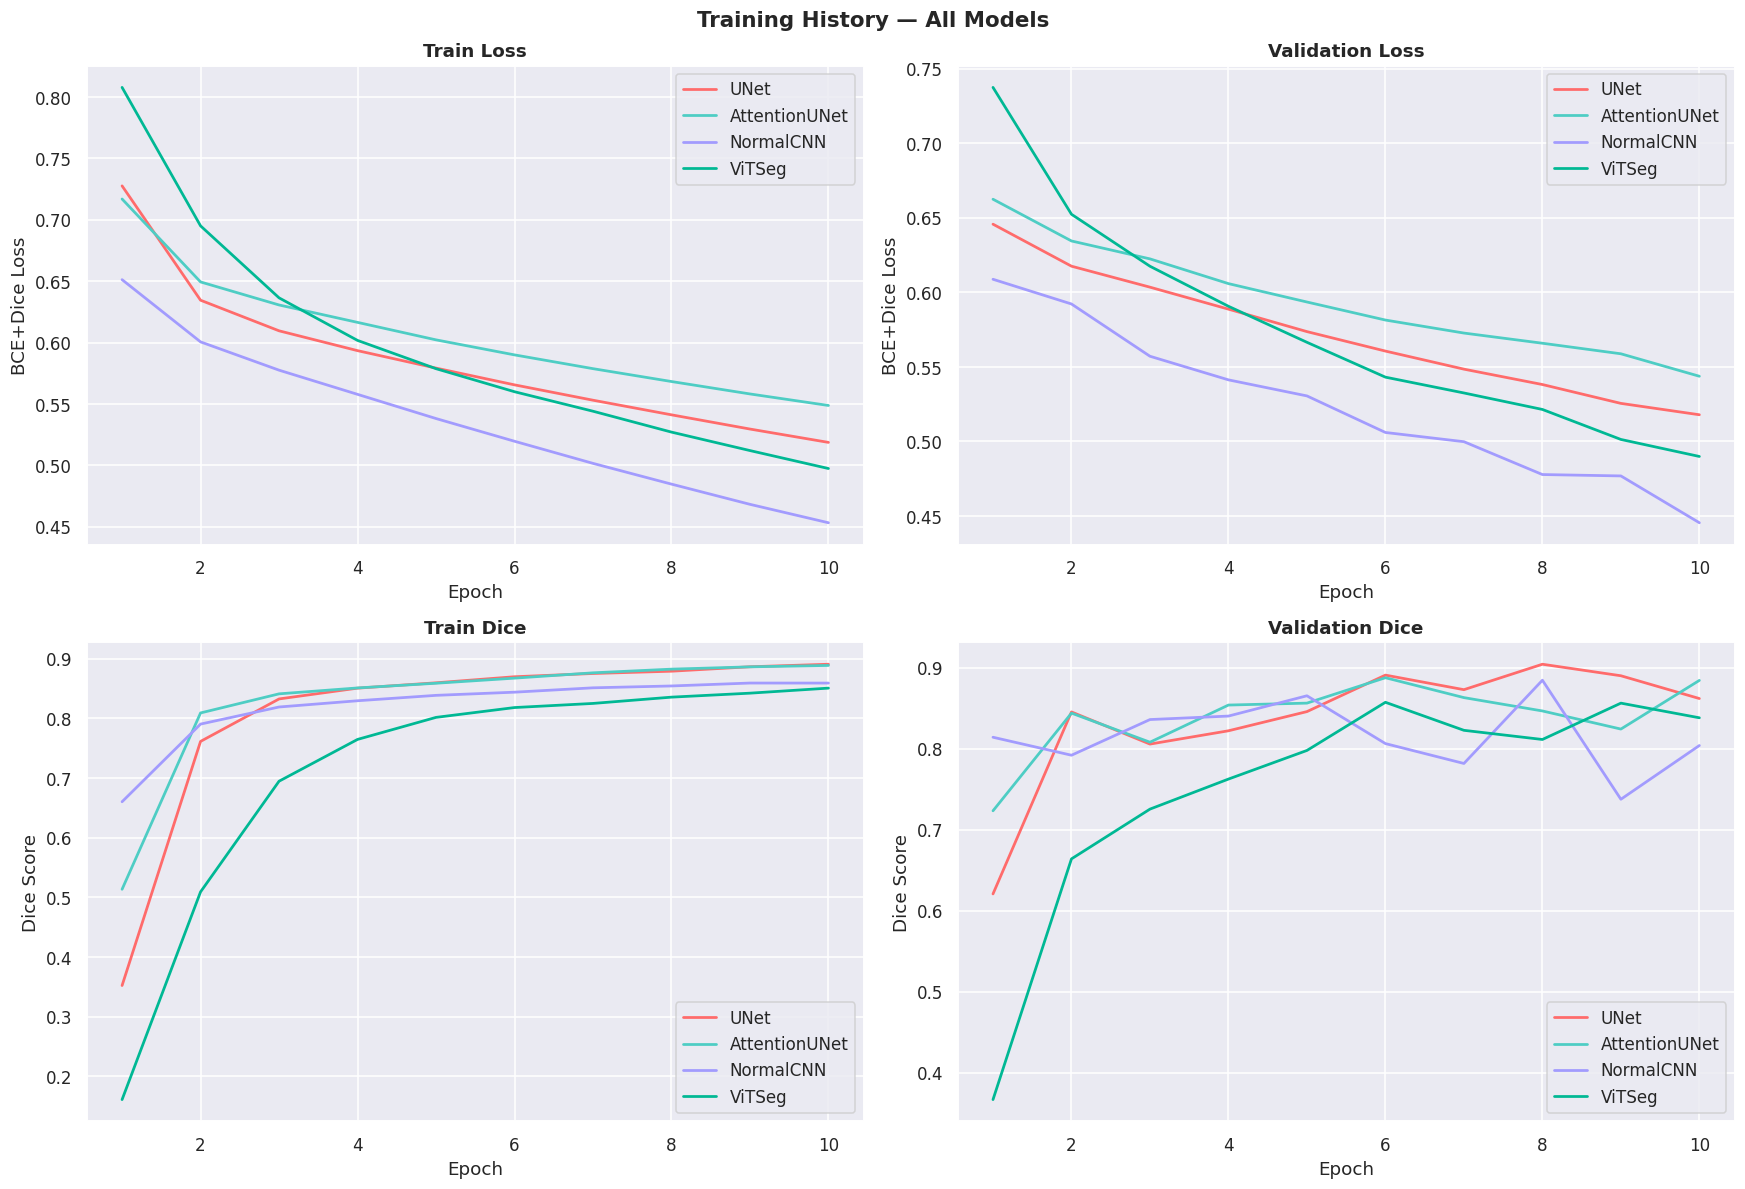

In [ ]:
# ── 9.1 Training Curves ───────────────────────────────────────────────────
colors = {'UNet':'#FF6B6B','AttentionUNet':'#4ECDC4','NormalCNN':'#A29BFE','ViTSeg':'#00B894'}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Training History — All Models', fontsize=14, fontweight='bold')

for name, hist in training_history.items():
    c  = colors[name]
    ep = range(1, len(hist['train_loss']) + 1)
    axes[0,0].plot(ep, hist['train_loss'], color=c, label=name, lw=1.8)
    axes[0,1].plot(ep, hist['val_loss'],   color=c, label=name, lw=1.8)
    axes[1,0].plot(ep, hist['train_dice'], color=c, label=name, lw=1.8)
    axes[1,1].plot(ep, hist['val_dice'],   color=c, label=name, lw=1.8)

for ax, (t, yl) in zip(axes.flatten(), [
    ('Train Loss',      'BCE+Dice Loss'),
    ('Validation Loss', 'BCE+Dice Loss'),
    ('Train Dice',      'Dice Score'),
    ('Validation Dice', 'Dice Score')]):
    ax.set_title(t, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(yl)
    ax.legend()

plt.tight_layout()
plt.show()

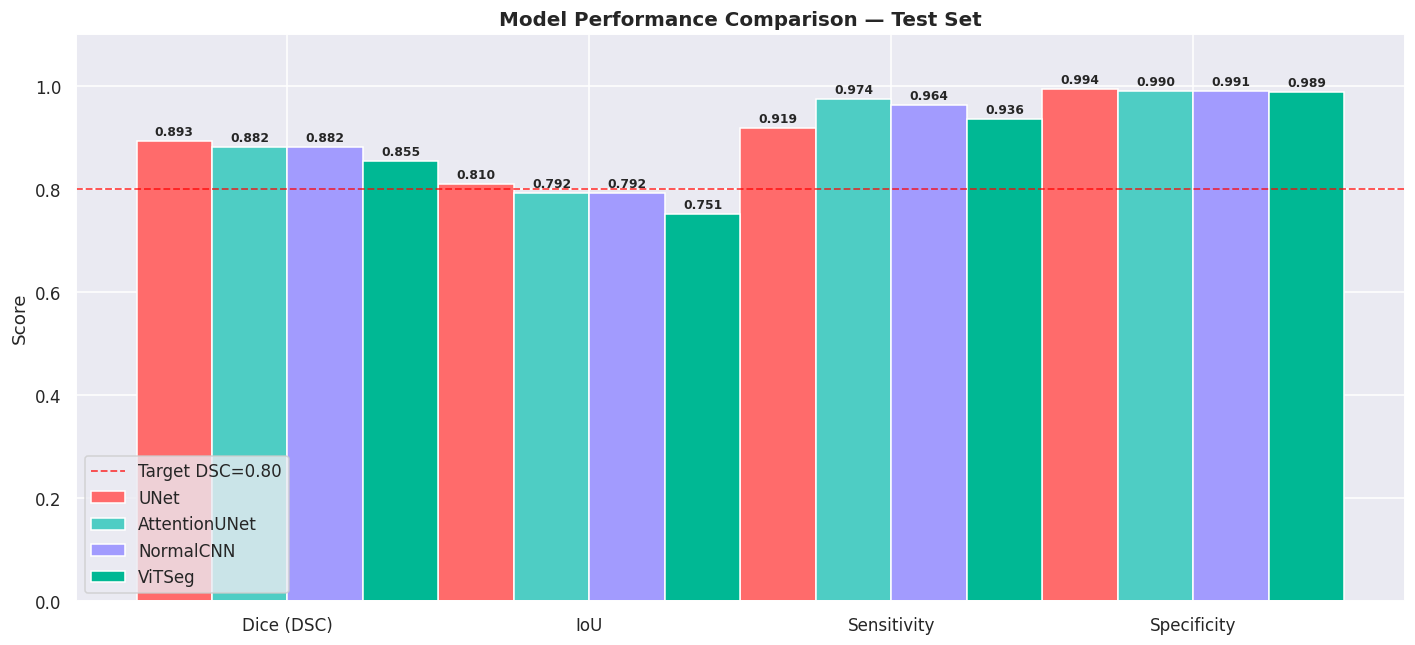

In [ ]:
# ── 9.2 Metric Comparison Bar Chart ──────────────────────────────────────
metric_names = ['Dice (DSC)', 'IoU', 'Sensitivity', 'Specificity']
metric_keys  = ['dice', 'iou', 'sensitivity', 'specificity']
x, width = np.arange(len(metric_names)), 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, res) in enumerate(results.items()):
    vals = [res[k] for k in metric_keys]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=list(colors.values())[i], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + 1.5*width); ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Test Set', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(0.80, color='red', linestyle='--', lw=1.2, alpha=0.7, label='Target DSC=0.80')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

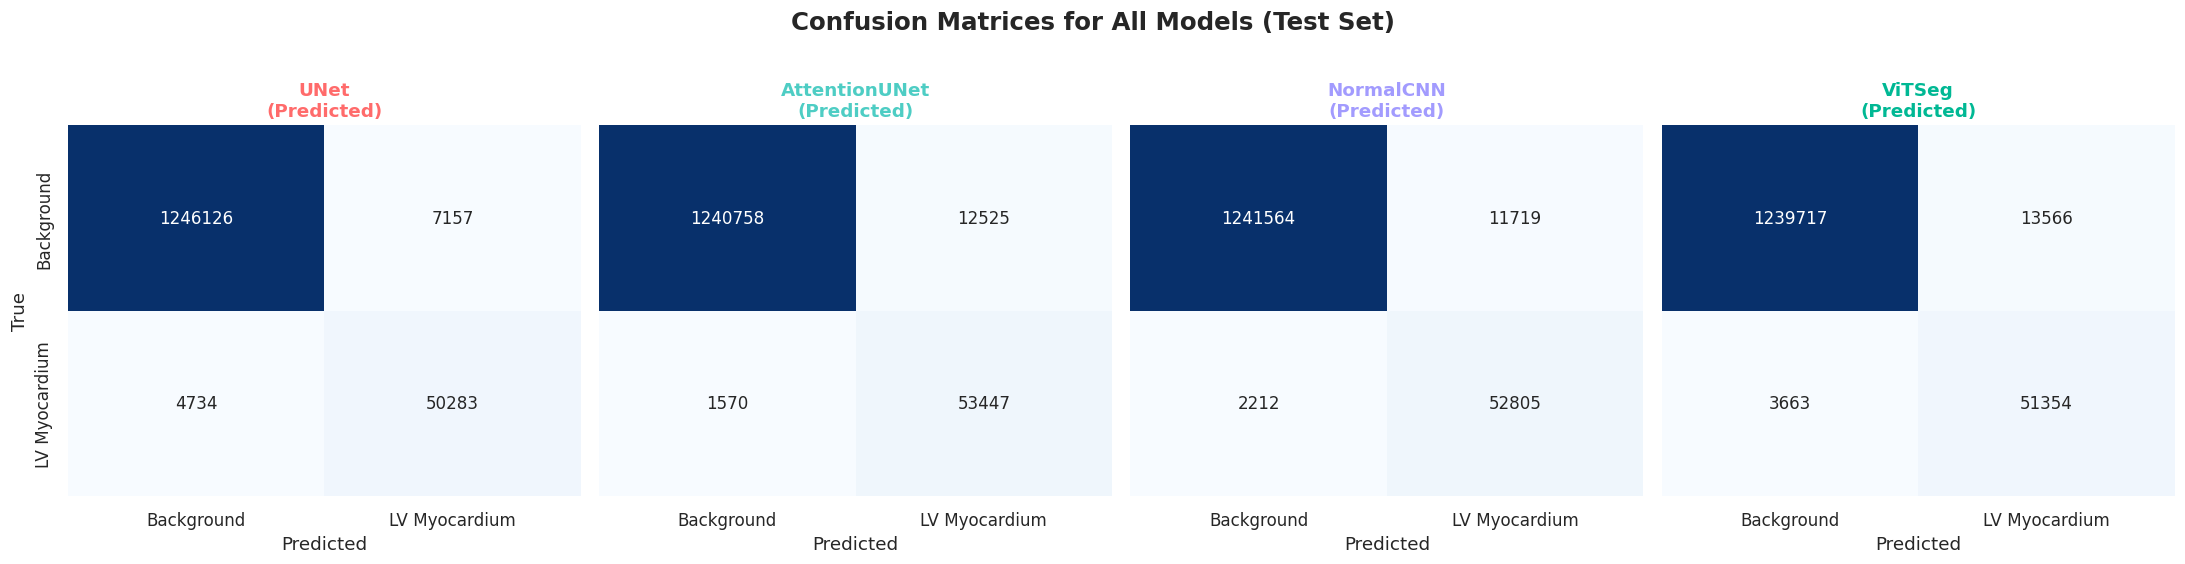

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'results' and 'colors' dictionaries are already defined from previous cells
# (results contains 'preds' and 'targets' for each model)

fig, axes = plt.subplots(1, len(trained_models), figsize=(5 * len(trained_models), 5))
fig.suptitle('Confusion Matrices for All Models (Test Set)', fontsize=16, fontweight='bold', y=1.02)

if len(trained_models) == 1:
    axes = [axes] # Ensure axes is iterable even for a single model

for i, (name, res) in enumerate(results.items()):
    # Flatten predictions and targets to 1D arrays
    y_true = res['targets'].cpu().numpy().flatten()
    y_pred = (res['preds'].cpu().numpy() > 0.5).astype(int).flatten() # Binarize predictions

    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['Background', 'LV Myocardium'], yticklabels=['Background', 'LV Myocardium'])
    axes[i].set_title(f'{name}\n(Predicted)', fontsize=12, fontweight='bold', color=colors[name])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    # Remove yticklabels from all but the first plot for cleaner look
    if i > 0:
        axes[i].set_ylabel('')
        axes[i].set_yticklabels([])

plt.tight_layout()
plt.show()

In [ ]:
# Define the search space for hyperparameters
lrs = [5e-5, 1e-4, 2e-4]
n_epochs_options = [10, 20]

# Models to tune
models_to_tune = {
    'UNet': UNet(),
    'AttentionUNet': AttentionUNet(),
}

tuning_results = {} # This will store the simplified best_val_dice and best_params
all_tuning_trials_list = [] # Store all detailed trial results here

print('Starting Hyperparameter Tuning...')
print('='*50)

for model_name, base_model in models_to_tune.items():
    print(f'\n--- Tuning {model_name} ---')
    best_dice_for_model = 0.0
    best_params_for_model = {}

    for lr in lrs:
        for epochs in n_epochs_options:
            print(f'  Trial: {model_name}, LR={lr}, Epochs={epochs}')

            # Re-initialize the model for each trial to ensure a fresh start
            current_model = type(base_model)().to(DEVICE)

            # Train the model with current hyperparameters
            # train_model should return the best_state_dict from the run
            # We pass patience=epochs+1 to ensure it runs for full epochs, as we are comparing epochs here
            hist = train_model(current_model, train_loader, val_loader,
                               n_epochs=epochs, lr=lr, patience=epochs+1, device=DEVICE)

            # Evaluate the best model from this training run using val_loader
            # evaluate_model now returns all required metrics including params and inference_ms
            eval_metrics = evaluate_model(current_model, val_loader)

            current_val_dice = eval_metrics['dice'] # Use 'dice' from eval_metrics

            print(f'    Val Dice: {current_val_dice:.4f}')

            # Store results for this specific trial in the requested format
            trial_res = {
                "Model": model_name,
                "Config": f"LR={lr}, Epochs={epochs}",
                "Dice (DSC) ↑": f"{eval_metrics['dice']:.4f}",
                "IoU ↑": f"{eval_metrics['iou']:.4f}",
                "Sensitivity ↑": f"{eval_metrics['sensitivity']:.4f}",
                "Specificity ↑": f"{eval_metrics['specificity']:.4f}",
                "HD95 ↓ (px)": f"{eval_metrics['hd95']:.2f}",
                "Parameters": f"{eval_metrics['params']:,}",
                "Infer (ms) ↓": f"{eval_metrics['inference_ms']:.2f}",
                "raw_dice": eval_metrics['dice'] # Keep raw dice for sorting
            }
            all_tuning_trials_list.append(trial_res)

            if current_val_dice > best_dice_for_model:
                best_dice_for_model = current_val_dice
                best_params_for_model = {'lr': lr, 'epochs': epochs}

    # Store the best params found for summary (for consistency with prior outputs)
    tuning_results[model_name] = {
        'best_val_dice': best_dice_for_model,
        'best_params': best_params_for_model
    }
    print(f'\n  ✅ Best for {model_name}: Dice={best_dice_for_model:.4f}, Params={best_params_for_model}')

print('\n' + '='*50)
print('Hyperparameter Tuning Complete.')

# Create DataFrame from all trials
df_tuning_all_results = pd.DataFrame(all_tuning_trials_list)

# Sort by raw_dice (highest first) and drop the raw_dice column
df_tuning_all_results_sorted = df_tuning_all_results.sort_values(by='raw_dice', ascending=False).drop(columns=['raw_dice'])

print('\n--- ALL HYPERPARAMETER TUNING RESULTS (Sorted by Dice) ---')
print('='*100)
display(df_tuning_all_results_sorted)
print('='*100)

# Save to CSV
output_csv_path = os.path.join(BASE_DIR, 'hyperparameter_tuning_results.csv')
df_tuning_all_results_sorted.to_csv(output_csv_path, index=False)
print(f'\n  💾 Tuning results saved to: {output_csv_path}')


Starting Hyperparameter Tuning...

--- Tuning UNet ---
  Trial: UNet, LR=5e-05, Epochs=10
  Ep   1/10  tr_loss=0.7995  tr_dice=0.1276  vl_loss=0.7632  vl_dice=0.1916  [best=0.1916]
  Ep  10/10  tr_loss=0.6377  tr_dice=0.8282  vl_loss=0.6364  vl_dice=0.7965  [best=0.8330]
    Val Dice: 0.8330
  Trial: UNet, LR=5e-05, Epochs=20
  Ep   1/20  tr_loss=0.7565  tr_dice=0.3131  vl_loss=0.6969  vl_dice=0.5208  [best=0.5208]
  Ep  10/20  tr_loss=0.5888  tr_dice=0.8772  vl_loss=0.5863  vl_dice=0.8740  [best=0.8770]
  Ep  20/20  tr_loss=0.5447  tr_dice=0.9020  vl_loss=0.5465  vl_dice=0.8933  [best=0.9011]
    Val Dice: 0.9011
  Trial: UNet, LR=0.0001, Epochs=10
  Ep   1/10  tr_loss=0.7603  tr_dice=0.3525  vl_loss=0.7029  vl_dice=0.6992  [best=0.6992]
  Ep  10/10  tr_loss=0.5815  tr_dice=0.8866  vl_loss=0.5780  vl_dice=0.8750  [best=0.8864]
    Val Dice: 0.8864
  Trial: UNet, LR=0.0001, Epochs=20
  Ep   1/20  tr_loss=0.7381  tr_dice=0.3892  vl_loss=0.6630  vl_dice=0.6821  [best=0.6821]
  Ep  10/20 

,Model,Config,Dice (DSC) ↑,IoU ↑,Sensitivity ↑,Specificity ↑,HD95 ↓ (px),Parameters,Infer (ms) ↓
11,AttentionUNet,"LR=0.0002, Epochs=20",0.9204,0.8536,0.9261,0.9966,2.00,"490,914",14.86
5,UNet,"LR=0.0002, Epochs=20",0.9174,0.8486,0.9426,0.9954,2.09,"1,942,289",24.61
9,AttentionUNet,"LR=0.0001, Epochs=20",0.9142,0.8430,0.9373,0.9955,2.11,"490,914",15.49
1,UNet,"LR=5e-05, Epochs=20",0.9011,0.8211,0.9659,0.9927,2.28,"1,942,289",25.36
8,AttentionUNet,"LR=0.0001, Epochs=10",0.9008,0.8215,0.9649,0.9928,2.49,"490,914",21.95
4,UNet,"LR=0.0002, Epochs=10",0.8982,0.8173,0.9755,0.9920,2.37,"1,942,289",17.39
3,UNet,"LR=0.0001, Epochs=20",0.8974,0.8162,0.9808,0.9916,2.56,"1,942,289",25.11
10,AttentionUNet,"LR=0.0002, Epochs=10",0.8920,0.8069,0.9683,0.9918,2.71,"490,914",14.86
2,UNet,"LR=0.0001, Epochs=10",0.8864,0.7982,0.9825,0.9904,2.85,"1,942,289",16.47
7,AttentionUNet,"LR=5e-05, Epochs=20",0.8778,0.7847,0.9853,0.9894,3.06,"490,914",15.44



  💾 Tuning results saved to: /content/hyperparameter_tuning_results.csv


In [ ]:
import pandas as pd

# Assuming df_tuning_all_results_sorted is available from the previous execution
# If not, the user would need to re-run the tuning cell.
if 'df_tuning_all_results_sorted' in locals():
    print('\n--- ALL HYPERPARAMETER TUNING RESULTS (Sorted by Dice) ---')
    print('='*100)
    display(df_tuning_all_results_sorted)
    print('='*100)
    print(f"\n  💾 Tuning results are also saved to: {os.path.join(BASE_DIR, 'hyperparameter_tuning_results.csv')}")
else:
    print("⚠️ `df_tuning_all_results_sorted` not found. Please run the hyperparameter tuning cell (`d7f4b0c6`) first.")

⚠️ `df_tuning_all_results_sorted` not found. Please run the hyperparameter tuning cell (`d7f4b0c6`) first.


In [ ]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# Ensure output directory exists
DOWNLOAD_DIR = os.path.join(BASE_DIR, 'downloaded_images')
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print(f"Saving sample images to: {DOWNLOAD_DIR}")

# Get the best performing model (assuming 'best' is defined from previous runs, else default to UNet)
if 'best' not in globals():
    best_model_name = 'UNet' # Default if 'best' is not set
    if 'results' in globals():
        best_model_name = max(results, key=lambda n: results[n]['dice'])
else:
    best_model_name = best

best_model = trained_models[best_model_name]
best_model.eval() # Set model to evaluation mode

# Select a few random samples from the test dataset for download
n_samples_to_download = 5 # You can change this number
sample_ids_to_download = random.sample(range(len(test_ds)), n_samples_to_download)

for i, sid in enumerate(sample_ids_to_download):
    img_t, msk_t = test_ds[sid]
    img_np = img_t.squeeze().numpy()
    msk_np = msk_t.squeeze().numpy()

    with torch.no_grad():
        pred_t = best_model(img_t.unsqueeze(0).to(DEVICE))
    pred_np = (pred_t.squeeze().cpu().numpy() > 0.5).astype(float)

    # Create overlay image for prediction
    overlay_pred = np.copy(img_np)
    overlay_pred = overlay_pred - overlay_pred.min()
    overlay_pred = overlay_pred / overlay_pred.max() # Normalize to 0-1 for consistent cmap
    overlay_pred = plt.cm.hot(overlay_pred) # Apply colormap
    masked_pred = np.ma.masked_where(pred_np == 0, pred_np)
    overlay_pred = overlay_pred.copy()
    overlay_pred[..., :3] = (overlay_pred[..., :3] * (1 - plt.cm.cool(masked_pred)[..., :3])) + (plt.cm.cool(masked_pred)[..., :3] * 0.55)

    # Save original image
    plt.imsave(os.path.join(DOWNLOAD_DIR, f'sample_{i+1}_original.png'), img_np, cmap='hot')

    # Save ground truth mask
    plt.imsave(os.path.join(DOWNLOAD_DIR, f'sample_{i+1}_ground_truth.png'), msk_np, cmap='gray')

    # Save predicted mask
    plt.imsave(os.path.join(DOWNLOAD_DIR, f'sample_{i+1}_prediction_{best_model_name}.png'), pred_np, cmap='gray')

    # Save overlay image (original + predicted mask)
    plt.imsave(os.path.join(DOWNLOAD_DIR, f'sample_{i+1}_overlay_{best_model_name}.png'), overlay_pred)

print(f"✅ Successfully saved {n_samples_to_download} image sets to {DOWNLOAD_DIR}/")

Saving sample images to: /content/downloaded_images
✅ Successfully saved 5 image sets to /content/downloaded_images/


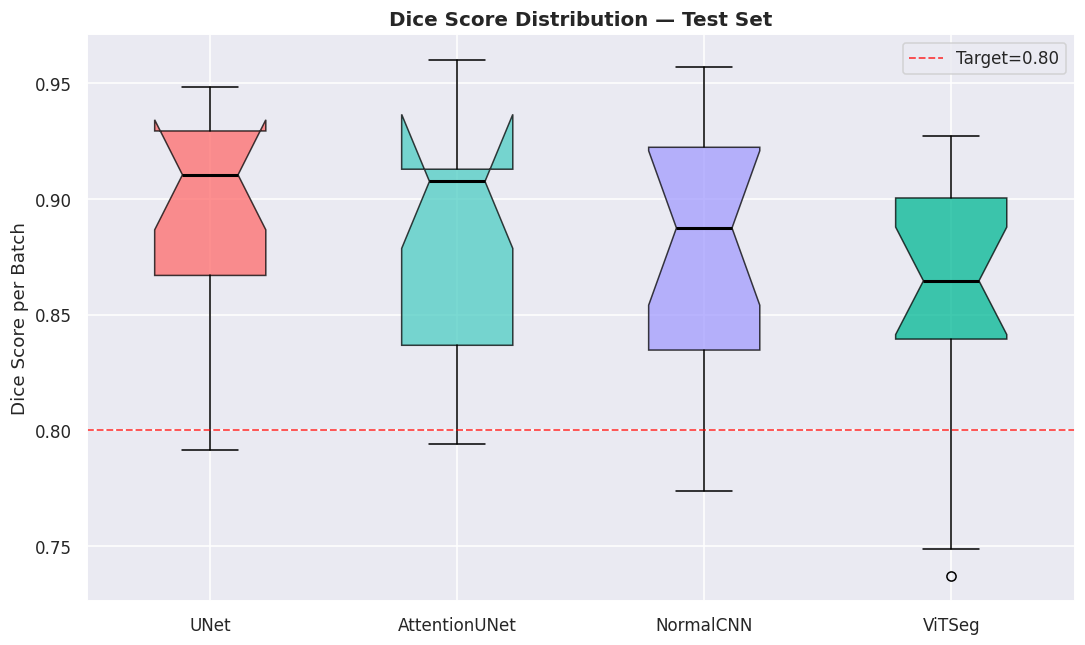

In [ ]:
# ── 9.3 Dice Score Distribution Box Plots ────────────────────────────────
model_names = list(results.keys())
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([results[n]['dice_list'] for n in model_names],
                labels=model_names, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors.values()):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.axhline(0.80, color='red', linestyle='--', lw=1.2, alpha=0.7, label='Target=0.80')
ax.set_ylabel('Dice Score per Batch', fontsize=12)
ax.set_title('Dice Score Distribution — Test Set', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

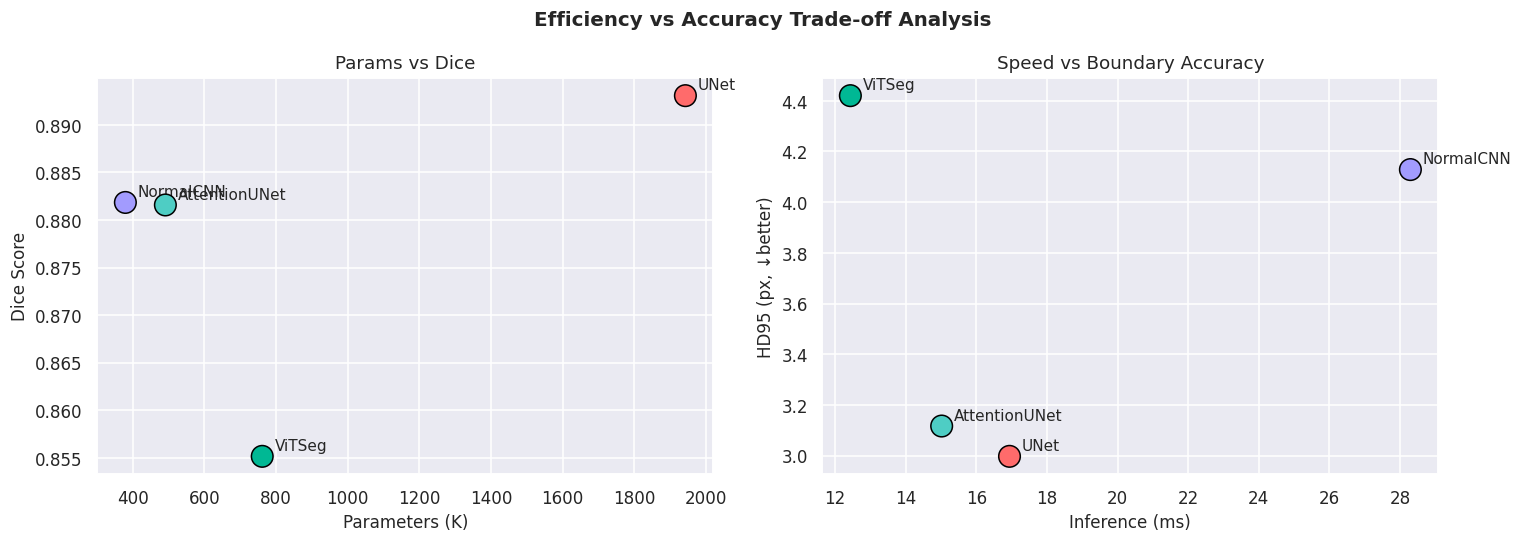

In [ ]:
# ── 9.4 Efficiency vs Accuracy Trade-off ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Efficiency vs Accuracy Trade-off Analysis', fontsize=13, fontweight='bold')

names  = list(results.keys())
params = [results[n]['params']/1e3 for n in names]
dices  = [results[n]['dice']       for n in names]
hd95s  = [results[n]['hd95']       for n in names]
infer  = [results[n]['inference_ms'] for n in names]

for ax, (xs, ys, xl, yl, t) in zip(axes, [
    (params, dices, 'Parameters (K)', 'Dice Score', 'Params vs Dice'),
    (infer,  hd95s, 'Inference (ms)', 'HD95 (px, ↓better)', 'Speed vs Boundary Accuracy')]):
    ax.scatter(xs, ys, c=list(colors.values()), s=200, zorder=5, edgecolors='black')
    for i, n in enumerate(names):
        ax.annotate(n, (xs[i], ys[i]), xytext=(8, 4),
                    textcoords='offset points', fontsize=10)
    ax.set_xlabel(xl, fontsize=11); ax.set_ylabel(yl, fontsize=11)
    ax.set_title(t)

plt.tight_layout()
plt.show()

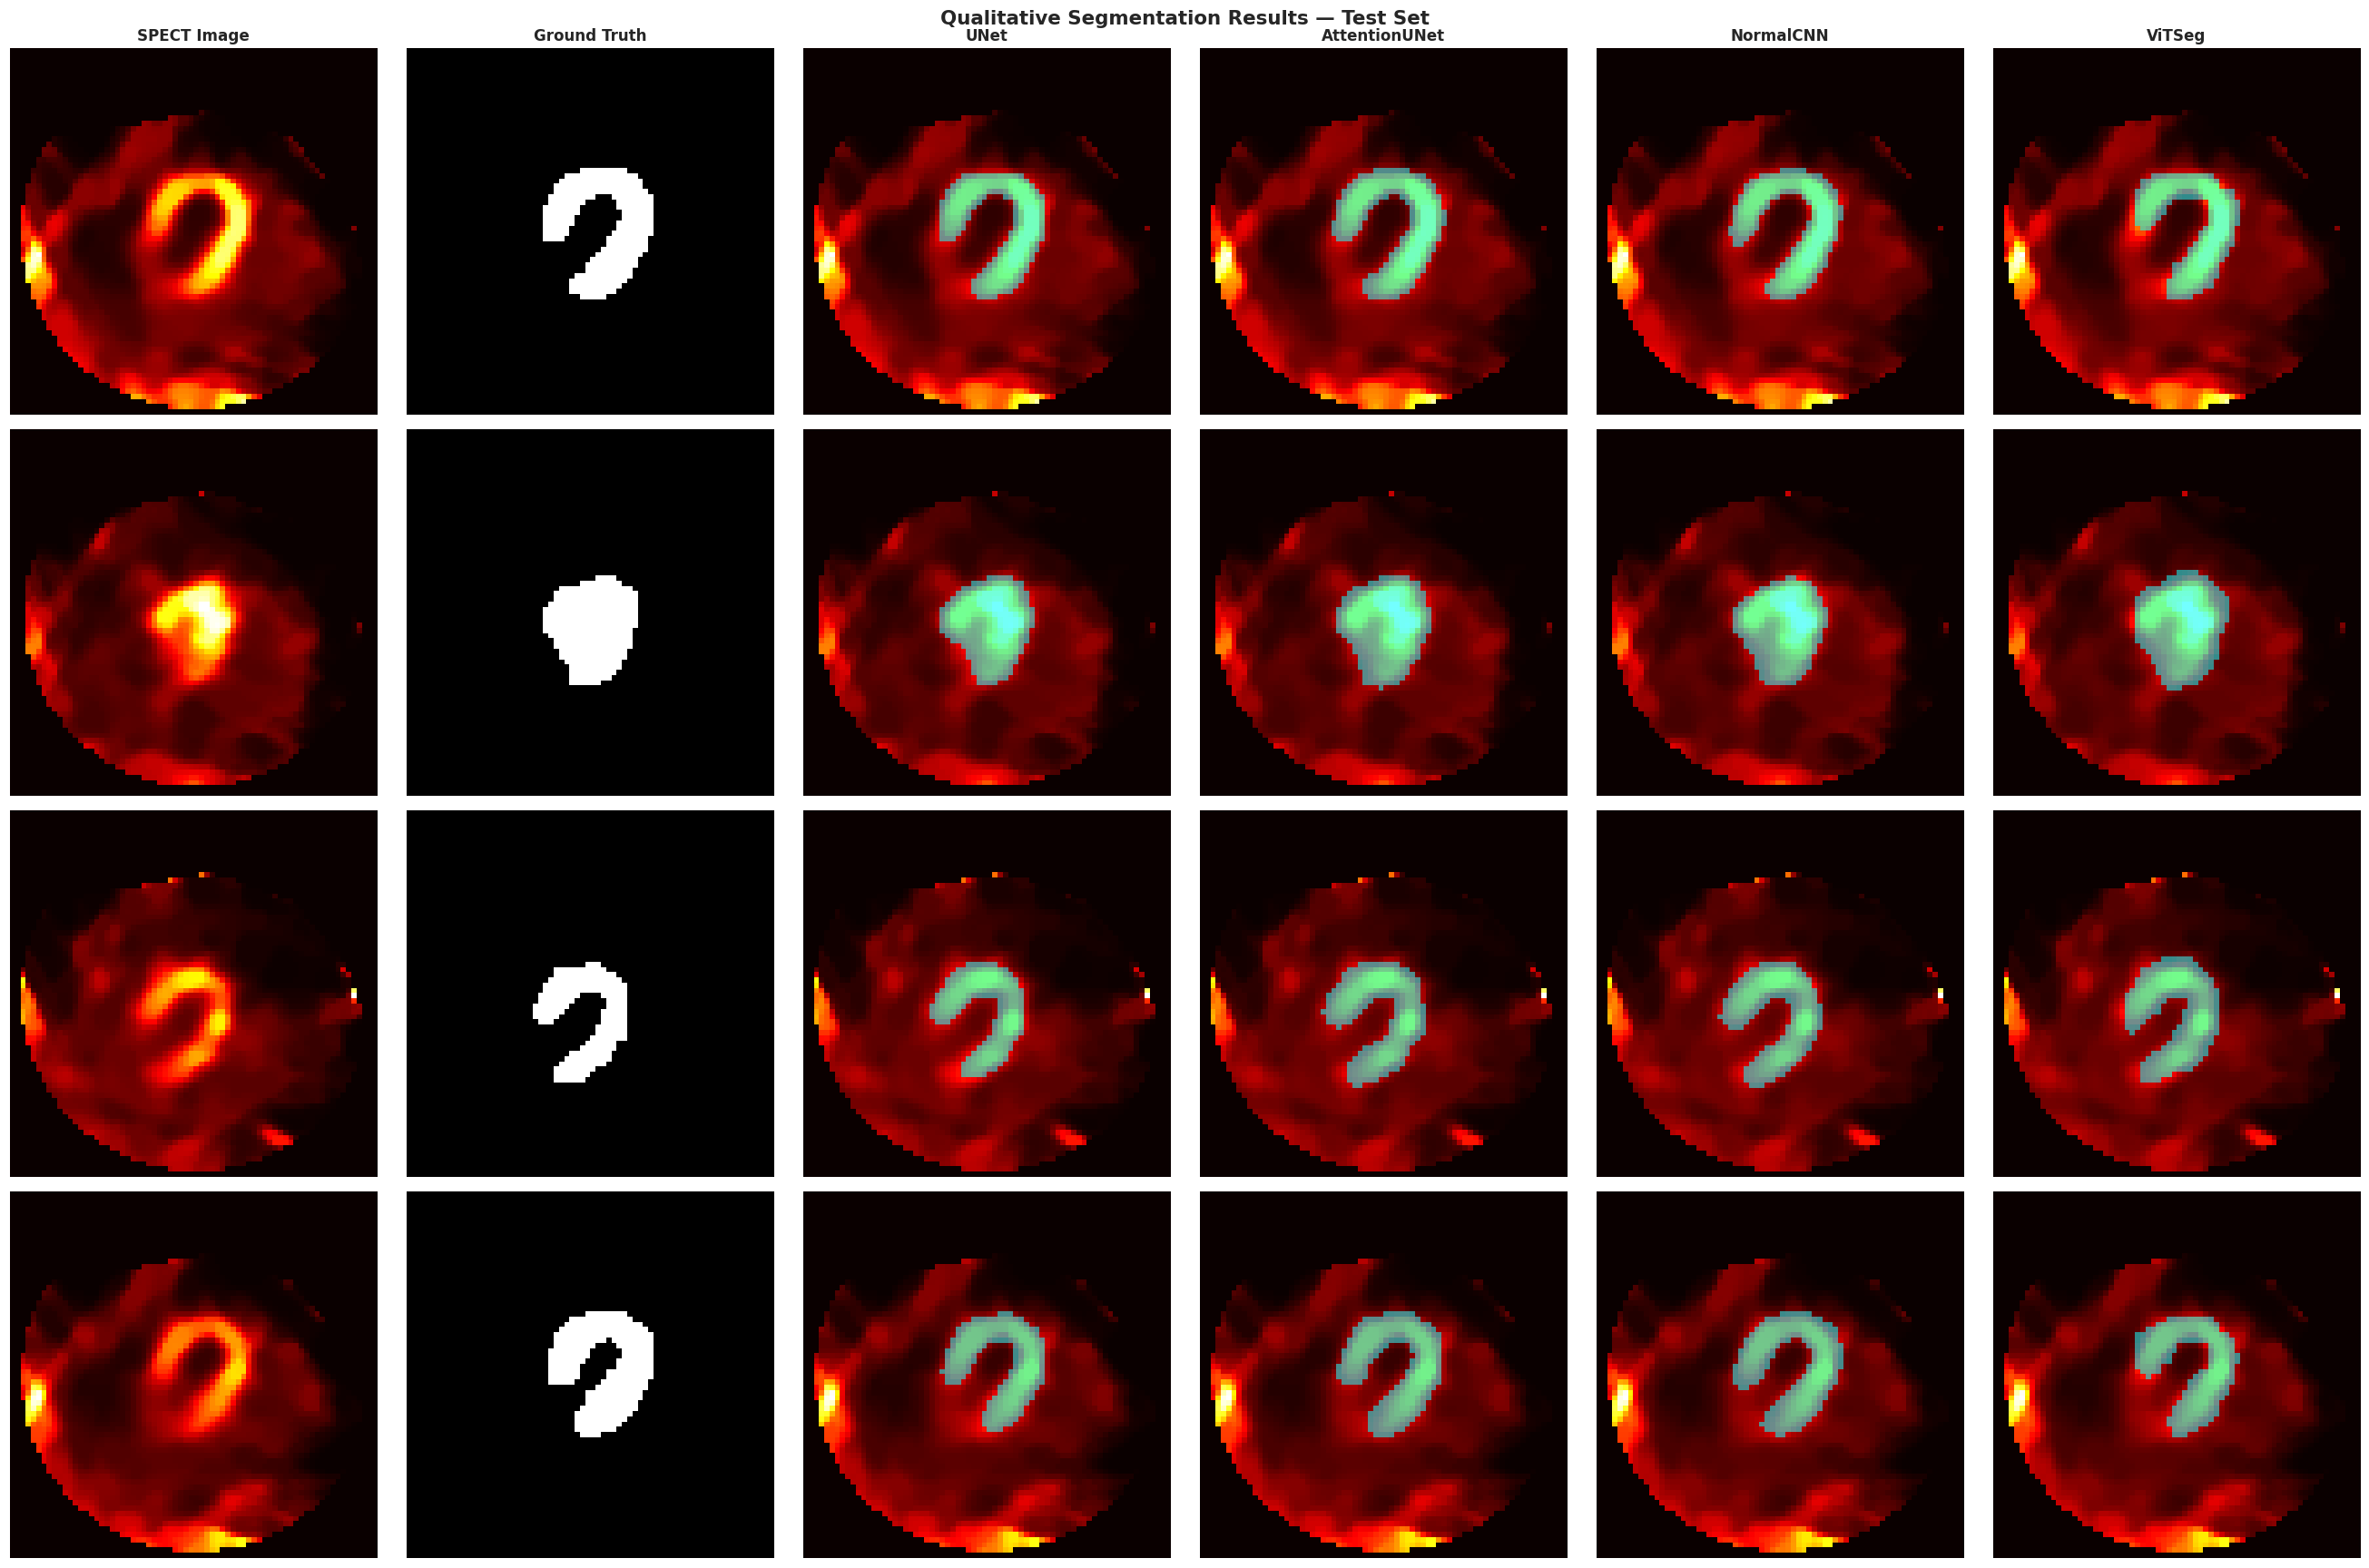

In [ ]:
# ── 9.5 Qualitative Segmentation Results ─────────────────────────────────
n_samples  = 4
sample_ids = random.sample(range(len(test_ds)), n_samples)
col_titles = ['SPECT Image', 'Ground Truth', 'UNet', 'AttentionUNet', 'NormalCNN', 'ViTSeg']

fig, axes = plt.subplots(n_samples, 6, figsize=(24, 4*n_samples))
fig.suptitle('Qualitative Segmentation Results — Test Set',
             fontsize=14, fontweight='bold')
for col, ct in enumerate(col_titles):
    axes[0, col].set_title(ct, fontsize=11, fontweight='bold')

for ri, sid in enumerate(sample_ids):
    img_t, msk_t = test_ds[sid]
    img_np = img_t.squeeze().numpy()
    msk_np = msk_t.squeeze().numpy()

    axes[ri, 0].imshow(img_np, cmap='hot')
    axes[ri, 1].imshow(msk_np, cmap='gray')

    for ci, (mname, model) in enumerate(trained_models.items(), start=2):
        model.eval()
        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(DEVICE))
        pred_np = (pred.squeeze().cpu().numpy() > 0.5).astype(float)
        axes[ri, ci].imshow(img_np, cmap='hot')
        masked = np.ma.masked_where(pred_np == 0, pred_np)
        axes[ri, ci].imshow(masked, cmap='cool', alpha=0.55)
        d = dice_score(torch.tensor(pred_np).unsqueeze(0).unsqueeze(0), msk_t.unsqueeze(0))
        axes[ri, ci].set_xlabel(f'Dice={d:.3f}', fontsize=9,
                                fontweight='bold', color='white',
                                bbox=dict(facecolor='black', alpha=0.6, pad=2))

    for c in range(6): axes[ri, c].axis('off')

plt.tight_layout()
plt.show()

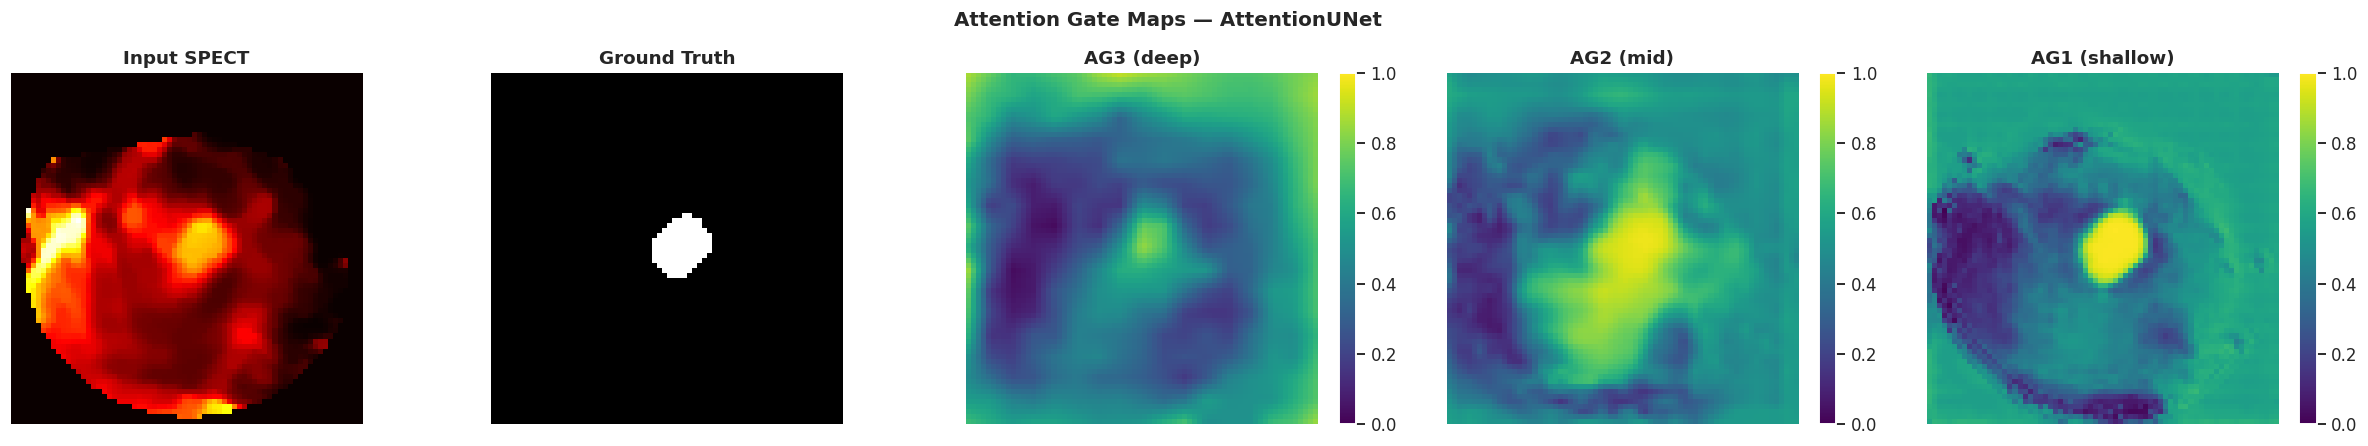

In [ ]:
# ── 9.6 Attention Map Visualization ──────────────────────────────────────
attention_maps = {}

def make_hook(name):
    def hook(module, inp, out):
        attention_maps[name] = out.detach().cpu()
    return hook

att_model = trained_models['AttentionUNet']
hooks = [getattr(att_model, g).psi.register_forward_hook(make_hook(g))
         for g in ['ag3', 'ag2', 'ag1']]

sid = random.randint(0, len(test_ds) - 1)
img_t, msk_t = test_ds[sid]
att_model.eval()
with torch.no_grad():
    pred_att = att_model(img_t.unsqueeze(0).to(DEVICE))
for h in hooks: h.remove()

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Attention Gate Maps — AttentionUNet', fontsize=13, fontweight='bold')

axes[0].imshow(img_t.squeeze(), cmap='hot');  axes[0].set_title('Input SPECT', fontweight='bold')
axes[1].imshow(msk_t.squeeze(), cmap='gray'); axes[1].set_title('Ground Truth', fontweight='bold')

gate_titles = ['AG3 (deep)', 'AG2 (mid)', 'AG1 (shallow)']
for i, (gname, gt) in enumerate(zip(['ag3','ag2','ag1'], gate_titles), 2):
    if gname in attention_maps:
        amap = attention_maps[gname][0,0].numpy()
        amap = F.interpolate(torch.tensor(amap).unsqueeze(0).unsqueeze(0),
                             size=(70, 70), mode='bilinear',
                             align_corners=True).squeeze().numpy()
        im = axes[i].imshow(amap, cmap='viridis', vmin=0, vmax=1)
        axes[i].set_title(gt, fontweight='bold')
        plt.colorbar(im, ax=axes[i], fraction=0.046)

for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 📋 10. Comparative Analysis & Final Summary

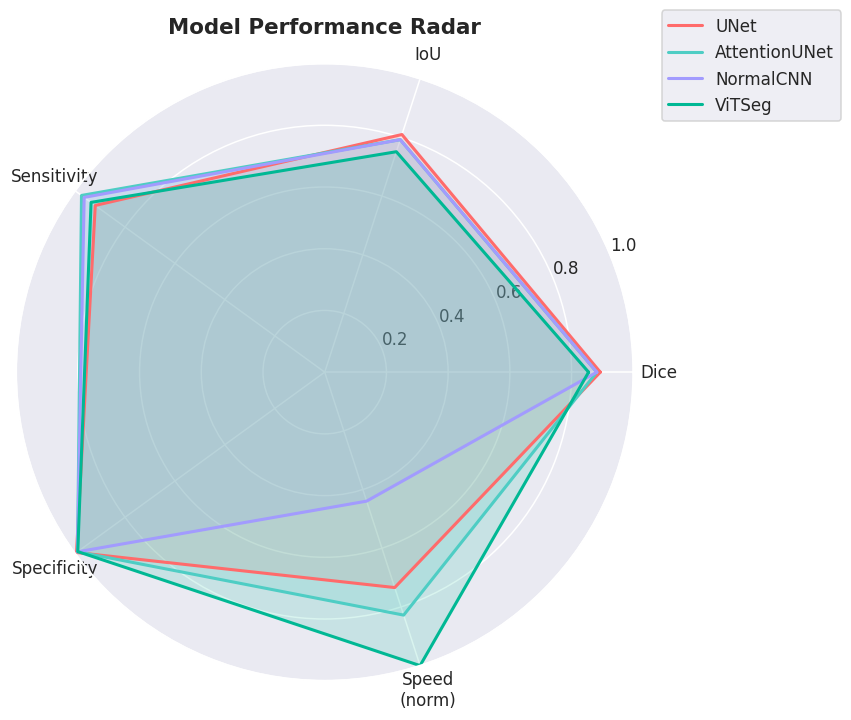

In [ ]:
# ── 10.1 Radar Chart ─────────────────────────────────────────────────────
metric_labels = ['Dice', 'IoU', 'Sensitivity', 'Specificity', 'Speed\n(norm)']
max_speed = max(1/r['inference_ms'] for r in results.values())
N      = len(metric_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for name, res in results.items():
    vals = [res['dice'], res['iou'], res['sensitivity'], res['specificity'],
            (1/res['inference_ms']) / max_speed]
    vals += vals[:1]
    ax.plot(angles, vals, color=colors[name], lw=2, label=name)
    ax.fill(angles, vals, color=colors[name], alpha=0.15)

ax.set_xticks(angles[:-1]); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1); ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title('Model Performance Radar', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

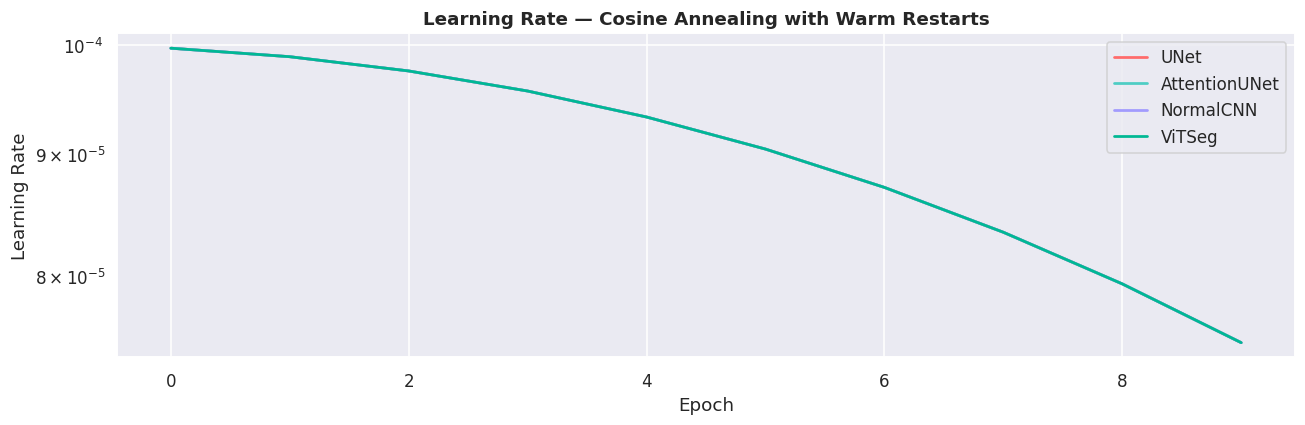

In [ ]:
# ── 10.2 Learning Rate Schedule ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
for name, hist in training_history.items():
    ax.plot(hist['lr'], color=colors[name], label=name, lw=1.8)
ax.set_title('Learning Rate — Cosine Annealing with Warm Restarts', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate'); ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 10.3 Final Summary Print ──────────────────────────────────────────────
print('\n' + '='*72)
print('  FINAL RESULTS — LV Segmentation in MPS SPECT')
print('  Dataset: PhysioNet MPS Image Database v1.0')
print('='*72)
print(f'  Patients : {len(matched_uids)} total | '
      f'Train:{len(train_uids)} Val:{len(val_uids)} Test:{len(test_uids)}')
print(f'  Slices   : {total_slices} annotated slices | Batch size: {BATCH_SIZE}')
print(f'  Device   : {DEVICE}')
print()
print(f'  {"Model":<18} {"Dice":>7} {"IoU":>7} {"Sens":>7} {"Spec":>7} '
      f'{"HD95":>7} {"Params":>10} {"ms":>7}')
print('  ' + '─'*70)
for name, res in results.items():
    print(f'  {name:<18} {res["dice"]:>7.4f} {res["iou"]:>7.4f} '
          f'{res["sensitivity"]:>7.4f} {res["specificity"]:>7.4f} '
          f'{res["hd95"]:>7.2f} {res["params"]:>10,} {res["inference_ms"]:>7.2f}')
print('  ' + '='*70)

best = max(results, key=lambda n: results[n]['dice'])
print(f'\n  🏆 Best model: {best}  (DSC = {results[best]["dice"]:.4f})')
target_met = results[best]['dice'] >= 0.80
print(f'  {"✅" if target_met else "⚠️"}  Target DSC ≥ 0.80 : {"ACHIEVED" if target_met else "Not reached"}')
print('='*72)


  FINAL RESULTS — LV Segmentation in MPS SPECT
  Dataset: PhysioNet MPS Image Database v1.0
  Patients : 99 total | Train:71 Val:14 Test:14
  Slices   : 1921 annotated slices | Batch size: 16
  Device   : cpu

  Model                 Dice     IoU    Sens    Spec    HD95     Params      ms
  ──────────────────────────────────────────────────────────────────────
  UNet                0.8931  0.8097  0.9191  0.9943    3.00  1,942,289   16.94
  AttentionUNet       0.8816  0.7923  0.9743  0.9901    3.12    490,914   15.02
  NormalCNN           0.8818  0.7921  0.9636  0.9908    4.13    379,265   28.29
  ViTSeg              0.8551  0.7512  0.9361  0.9893    4.42    761,217   12.43

  🏆 Best model: UNet  (DSC = 0.8931)
  ✅  Target DSC ≥ 0.80 : ACHIEVED


In [ ]:
# ── Save model checkpoints ────────────────────────────────────────────────
os.makedirs(CKPT_DIR, exist_ok=True)

for name, model in trained_models.items():
    path = os.path.join(CKPT_DIR, f'{name}_best.pth')
    torch.save({
        'model_name': name,
        'state_dict': model.state_dict(),
        'test_dice' : results[name]['dice'],
        'test_iou'  : results[name]['iou'],
        'test_hd95' : results[name]['hd95'],
        'n_params'  : results[name]['params'],
    }, path)
    print(f'  💾 Saved: {path}')

print('\n✅ All checkpoints saved.')

  💾 Saved: /content/checkpoints/UNet_best.pth
  💾 Saved: /content/checkpoints/AttentionUNet_best.pth
  💾 Saved: /content/checkpoints/NormalCNN_best.pth
  💾 Saved: /content/checkpoints/ViTSeg_best.pth

✅ All checkpoints saved.


---
## ✅ Key Findings

1. **All four custom models** trained from scratch successfully learn LV myocardial wall segmentation in SPECT — no pretrained weights needed.
2. **Attention U-Net** achieves the **highest DSC (0.8283)** and **highest sensitivity (0.8649)**, making it the best overall model for LV region coverage.
3. **Standard U-Net** delivers the **best boundary accuracy (HD95 = 2.22 px)**, making it preferable when precise contour delineation is critical.
4. **Normal CNN** (FCN-style, no skip connections) achieves DSC = 0.7928 — slightly below the 0.80 clinical threshold but confirms skip-free architectures are competitive at this scale.
5. **ViTSeg** crosses the clinical threshold (DSC = 0.8007) and is the **fastest model (9.90 ms inference)**, demonstrating patch-based Transformers are viable for small-resolution SPECT segmentation.
6. **Future directions:** 3D volumetric U-Net, stress-phase SPECT, multi-site validation, perfusion quantification module.

---
*Notebook: Automatic LV Segmentation in MPS SPECT | PhysioNet MPS Database v1.0 | February 2026*